# seoul_air_trend_2019_2026_analysis

## 서울시 대기질 2019~2026 종합 분석 및 결론

이 노트북은 앞 단계의 시각화 EDA를 바탕으로 **데이터 품질 → 장기 추세 → 계절성 → 시간대 패턴 → 지역 차이 → 기존 가설 재검증 → 최종 결론**까지 연결한다.

이번 단계의 목적은 그래프를 더 많이 만드는 것이 아니라, 그래프에서 보인 패턴을 **수치로 요약하고 결론을 내리는 것**이다.

> **중요:** 2026년은 부분연도일 수 있으므로 2019~2025 완전연도 장기 추세와 분리해서 해석한다.  
> 2026년은 동일한 월·일 범위의 과거 자료와 비교하여 최근 수준을 확인한다.


# 1. 분석 해석 순서

## A. 데이터 품질

먼저 확인한다.

1. 각 연도에 25개 측정소가 모두 존재하는가?
2. 특정 연도·측정소에서 결측이 급증하는가?
3. 0값이 특정 기간이나 측정소에 몰려 있는가?
4. 2026년 데이터가 어디까지 존재하는가?

## B. 장기 추세

`월별 장기 추세`를 본다.

- 2019 이후 농도가 장기적으로 올라가는가 / 내려가는가?
- 특정 연도만 비정상적으로 높은가?
- 2026년 현재까지의 수준은 과거와 다른가?

## C. 계절성

`평균 1~12월 계절성`과 `연도별 월 패턴`을 같이 본다.

- 특정 달마다 반복적으로 높아지는가?
- 그 패턴이 해마다 유지되는가?
- 측정소마다 계절성의 크기가 다른가?

## D. 시간대 패턴

`평균 24시간 패턴`을 본다.

- 새벽 / 오전 / 오후 / 저녁 중 반복적인 차이가 존재하는가?
- 오존과 NO₂가 서로 다른 시간 패턴을 보이는가?
- PM 계열에서도 의미 있는 시간 패턴이 존재하는가?

시간별 raw line은 특정 episode를 보는 용도이고, 반복적인 시간 패턴은 평균 24시간 profile로 확인한다.

## E. 지역 차이

다음을 함께 본다.

1. 측정소 × 월 heatmap
2. 서울 평균 대비 지역 편차

- 특정 측정소가 장기간 상대적으로 높은가 / 낮은가?
- 지역 우위가 모든 계절에 유지되는가?
- 특정 달에만 지역 순위가 바뀌는가?

## F. 이전 분석과의 관계

이전 짧은 기간 분석에서는 PM10·PM2.5의 월별 계절성, 오존의 시간대 패턴, 서울 평균 대비 지역 편차 등이 중요한 후보로 보였다.

이번 2019~2026 분석에서는 그 결론을 그대로 사용하지 않고 **가설로만 두고 재검증**한다.

```text
과거 결과
    ↓
가설
    ↓
2019~2026 시각화
    ↓
재검증
```

## 이번 단계의 목표

아직 AirScore를 만드는 것이 아니다.

먼저 다음을 명확하게 파악한다.

```text
지역 차이
시간대 패턴
계절성
장기 추세
데이터 품질
```

그 다음 단계에서 필요한 경우 `gu × month × hour` 형태의 historical air climatology feature table을 만든다.


## 2. 라이브러리

In [1]:
from pathlib import Path
import re
import unicodedata
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2-1. 한글 폰트 설정

Matplotlib의 한글 깨짐과 마이너스 기호 깨짐을 방지한다.


In [2]:
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

print("한글 폰트:", plt.rcParams["font.family"])

한글 폰트: ['Malgun Gothic']


## 3. 데이터 로드

앞 단계에서 생성한 아래 파일을 우선 사용한다.

```text
air_quality_analysis/air_hourly_clean_2019_2026.csv
```

이 파일이 없으면 `raw_air/yearly/seoul_air_2019.csv` ~ `raw_air/yearly/seoul_air_2026.csv`를 직접 읽어 표준화한다.


In [3]:
PROJECT_DIR = Path(
    r"C:\Users\Luke\Desktop\DArtB\Toyproject"
)

RAW_DIR = PROJECT_DIR / "raw_air"
YEARLY_DIR = RAW_DIR / "yearly"

ANALYSIS_DIR = (
    PROJECT_DIR
    / "air_quality_analysis"
)

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CLEAN_HOURLY_PATH = (
    ANALYSIS_DIR
    / "air_hourly_clean_2019_2026.csv"
)

print("PROJECT_DIR       :", PROJECT_DIR)
print("RAW_DIR           :", RAW_DIR)
print("YEARLY_DIR        :", YEARLY_DIR)
print("ANALYSIS_DIR      :", ANALYSIS_DIR)
print("CLEAN_HOURLY_PATH :", CLEAN_HOURLY_PATH)

PROJECT_DIR       : C:\Users\Luke\Desktop\DArtB\Toyproject
RAW_DIR           : C:\Users\Luke\Desktop\DArtB\Toyproject\raw_air
YEARLY_DIR        : C:\Users\Luke\Desktop\DArtB\Toyproject\raw_air\yearly
ANALYSIS_DIR      : C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis
CLEAN_HOURLY_PATH : C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\air_hourly_clean_2019_2026.csv


In [4]:
ENCODINGS = [
    "utf-8-sig",
    "utf-8",
    "cp949",
    "euc-kr"
]

COLUMN_ALIASES = {
    "datetime": [
        "datetime",
        "MSRMT_DT",
        "측정일시",
        "측정일자"
    ],
    "station": [
        "station",
        "MSRSTN_NM",
        "측정소명",
        "측정소"
    ],
    "pm10_1h": [
        "pm10_1h",
        "PM_HOUR",
        "미세먼지1시간(㎍/㎥)",
        "미세먼지 1시간(㎍/㎥)",
        "미세먼지 1시간"
    ],
    "pm10_24h": [
        "pm10_24h",
        "PM_DAY",
        "미세먼지24시간(㎍/㎥)",
        "미세먼지 24시간(㎍/㎥)",
        "미세먼지 24시간"
    ],
    "pm25": [
        "pm25",
        "FPM",
        "초미세먼지(㎍/㎥)",
        "초미세먼지"
    ],
    "o3": [
        "o3",
        "OZON",
        "오존(ppm)",
        "오존"
    ],
    "no2": [
        "no2",
        "NTDX",
        "이산화질소농도(ppm)",
        "이산화질소"
    ],
    "co": [
        "co",
        "CBMX",
        "일산화탄소농도(ppm)",
        "일산화탄소"
    ],
    "so2": [
        "so2",
        "SPDX",
        "아황산가스농도(ppm)",
        "아황산가스"
    ],
}

POLLUTANTS = {
    "pm10_1h": "미세먼지 1시간 (㎍/㎥)",
    "pm10_24h": "미세먼지 24시간 (㎍/㎥)",
    "pm25": "초미세먼지 (㎍/㎥)",
    "o3": "오존 (ppm)",
    "no2": "이산화질소 (ppm)",
    "co": "일산화탄소 (ppm)",
    "so2": "아황산가스 (ppm)"
}


def read_csv_safe(path):
    last_error = None

    for enc in ENCODINGS:
        try:
            return pd.read_csv(
                path,
                encoding=enc,
                low_memory=False
            )
        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"CSV 읽기 실패: {path}\n{last_error}"
    )


def normalize_label(text):
    text = unicodedata.normalize(
        "NFKC",
        str(text)
    )
    text = text.lower().strip()
    text = re.sub(r"\s+", "", text)
    text = text.replace("μ", "u").replace("㎍", "ug")
    text = re.sub(
        r"[^0-9a-z가-힣]+",
        "",
        text
    )
    return text


def find_column(df, aliases):
    lookup = {
        normalize_label(col): col
        for col in df.columns
    }

    for alias in aliases:
        key = normalize_label(alias)

        if key in lookup:
            return lookup[key]

    return None


def standardize_frame(df, source_year=None):
    rename_map = {}

    for std_name, aliases in COLUMN_ALIASES.items():
        col = find_column(df, aliases)

        if col is not None:
            rename_map[col] = std_name

    out = df.rename(
        columns=rename_map
    ).copy()

    if "datetime" not in out.columns:
        raise ValueError(
            "datetime/MSRMT_DT 컬럼을 찾지 못했습니다."
        )

    if "station" not in out.columns:
        raise ValueError(
            "station/MSRSTN_NM 컬럼을 찾지 못했습니다."
        )

    raw_dt = (
        out["datetime"]
        .astype(str)
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
        .str.strip()
    )

    dt1 = pd.to_datetime(
        raw_dt,
        format="%Y%m%d%H%M",
        errors="coerce"
    )

    dt2 = pd.to_datetime(
        raw_dt,
        errors="coerce"
    )

    out["datetime"] = dt1.fillna(dt2)

    for col in POLLUTANTS:
        if col in out.columns:
            out[col] = pd.to_numeric(
                out[col],
                errors="coerce"
            )

    out["station"] = (
        out["station"]
        .astype(str)
        .str.strip()
    )

    keep = [
        "datetime",
        "station",
        *[
            c for c in POLLUTANTS
            if c in out.columns
        ]
    ]

    return out[keep]


def load_air_data():
    if CLEAN_HOURLY_PATH.exists():
        print(
            "✓ 정제 hourly 파일 사용:",
            CLEAN_HOURLY_PATH
        )

        raw = read_csv_safe(
            CLEAN_HOURLY_PATH
        )

        return standardize_frame(raw)

    print(
        "정제 hourly 파일이 없어 "
        "연도별 파일을 직접 통합합니다."
    )

    frames = []

    for year in range(2019, 2027):

        path = (
            YEARLY_DIR
            / f"seoul_air_{year}.csv"
        )

        if not path.exists():

            matches = sorted(
                p
                for p in YEARLY_DIR.glob("*.csv")
                if str(year) in p.name
                and "air" in p.name.lower()
            )

            path = (
                matches[0]
                if matches
                else None
            )

        if path is None:
            print(f"✗ {year}: 파일 없음")
            continue

        temp = standardize_frame(
            read_csv_safe(path),
            source_year=year
        )

        frames.append(temp)

        print(
            f"✓ {year}: "
            f"{len(temp):,} rows"
        )

    if not frames:
        raise RuntimeError(
            "사용할 대기질 파일이 없습니다."
        )

    return pd.concat(
        frames,
        ignore_index=True,
        sort=False
    )


air_raw = load_air_data()

print("\nRAW shape:", air_raw.shape)
print(
    "기간:",
    air_raw["datetime"].min(),
    "~",
    air_raw["datetime"].max()
)

정제 hourly 파일이 없어 연도별 파일을 직접 통합합니다.
✓ 2019: 219,000 rows
✓ 2020: 219,598 rows
✓ 2021: 219,000 rows
✓ 2022: 219,000 rows
✓ 2023: 219,000 rows
✓ 2024: 219,599 rows
✓ 2025: 219,000 rows
✓ 2026: 159,235 rows

RAW shape: (1693432, 9)
기간: 2019-01-01 00:00:00 ~ 2026-09-25 16:00:00


## 4. 분석용 데이터 준비

데이터 품질 분석은 원자료를 최대한 그대로 사용하고, 추세 분석에서는 다음만 적용한다.

- datetime/station 결측 행 제거
- 완전 중복 제거
- 음수 농도 → `NaN`
- 같은 `datetime × station` 중복이 있으면 평균
- **0값은 임의로 제거하지 않음** — 별도로 발생률을 계산하여 판단


In [5]:
AVAILABLE_POLLUTANTS = [
    c for c in POLLUTANTS
    if c in air_raw.columns
]

air = air_raw.copy()

air = air[
    air["datetime"].notna()
    &
    air["station"].notna()
].copy()

air = air.drop_duplicates()

for col in AVAILABLE_POLLUTANTS:
    air.loc[
        air[col] < 0,
        col
    ] = np.nan

air = (
    air
    .groupby(
        ["datetime", "station"],
        as_index=False
    )[AVAILABLE_POLLUTANTS]
    .mean()
    .sort_values(
        ["datetime", "station"]
    )
    .reset_index(drop=True)
)

air["year"] = air["datetime"].dt.year
air["month"] = air["datetime"].dt.month
air["hour"] = air["datetime"].dt.hour
air["date"] = air["datetime"].dt.floor("D")
air["year_month"] = (
    air["datetime"]
    .dt.to_period("M")
    .astype(str)
)

stations = sorted(
    air["station"]
    .dropna()
    .unique()
)

station_code_map = pd.DataFrame({
    "code": range(len(stations)),
    "station": stations
})

print("사용 가능한 오염물질:", AVAILABLE_POLLUTANTS)
print("측정소 수:", len(stations))
display(station_code_map)

사용 가능한 오염물질: ['pm10_1h', 'pm10_24h', 'pm25', 'o3', 'no2', 'co', 'so2']
측정소 수: 25


,code,station
0,0,강남구
1,1,강동구
2,2,강북구
3,3,강서구
4,4,관악구
5,5,광진구
6,6,구로구
7,7,금천구
8,8,노원구
9,9,도봉구


# 5. A. 데이터 품질

다음 네 가지를 실제 수치로 확인한다.

1. 연도별 측정소 수
2. 연도 × 측정소별 관측 완전성
3. 오염물질별 결측률 / 0값 비율
4. 2026년 마지막 관측 시각


In [6]:
year_coverage = (
    air
    .groupby("year")
    .agg(
        rows=("station", "size"),
        station_count=("station", "nunique"),
        start=("datetime", "min"),
        end=("datetime", "max")
    )
    .reset_index()
)

display(year_coverage)

missing_station_years = (
    year_coverage.loc[
        year_coverage["station_count"] != 25,
        ["year", "station_count"]
    ]
)

if len(missing_station_years) == 0:
    print("✓ 모든 연도에 25개 측정소가 존재합니다.")
else:
    print("⚠ 25개 측정소가 아닌 연도:")
    display(missing_station_years)

,year,rows,station_count,start,end
0,2019,219000,25,2019-01-01,2019-12-31 23:00:00
1,2020,219598,25,2020-01-01,2020-12-31 23:00:00
2,2021,219000,25,2021-01-01,2021-12-31 23:00:00
3,2022,219000,25,2022-01-01,2022-12-31 23:00:00
4,2023,219000,25,2023-01-01,2023-12-31 23:00:00
5,2024,219599,25,2024-01-01,2024-12-31 23:00:00
6,2025,219000,25,2025-01-01,2025-12-31 23:00:00
7,2026,159235,25,2026-01-01,2026-09-25 16:00:00


✓ 모든 연도에 25개 측정소가 존재합니다.


,year,station,observed_hours,expected_hours,coverage_rate
188,2026,서대문구,6330,6425,0.9852
187,2026,마포구,6353,6425,0.9888
190,2026,성동구,6362,6425,0.9902
180,2026,광진구,6368,6425,0.9911
193,2026,양천구,6368,6425,0.9911
175,2026,강남구,6369,6425,0.9913
177,2026,강북구,6370,6425,0.9914
181,2026,구로구,6371,6425,0.9916
199,2026,중랑구,6371,6425,0.9916
194,2026,영등포구,6371,6425,0.9916


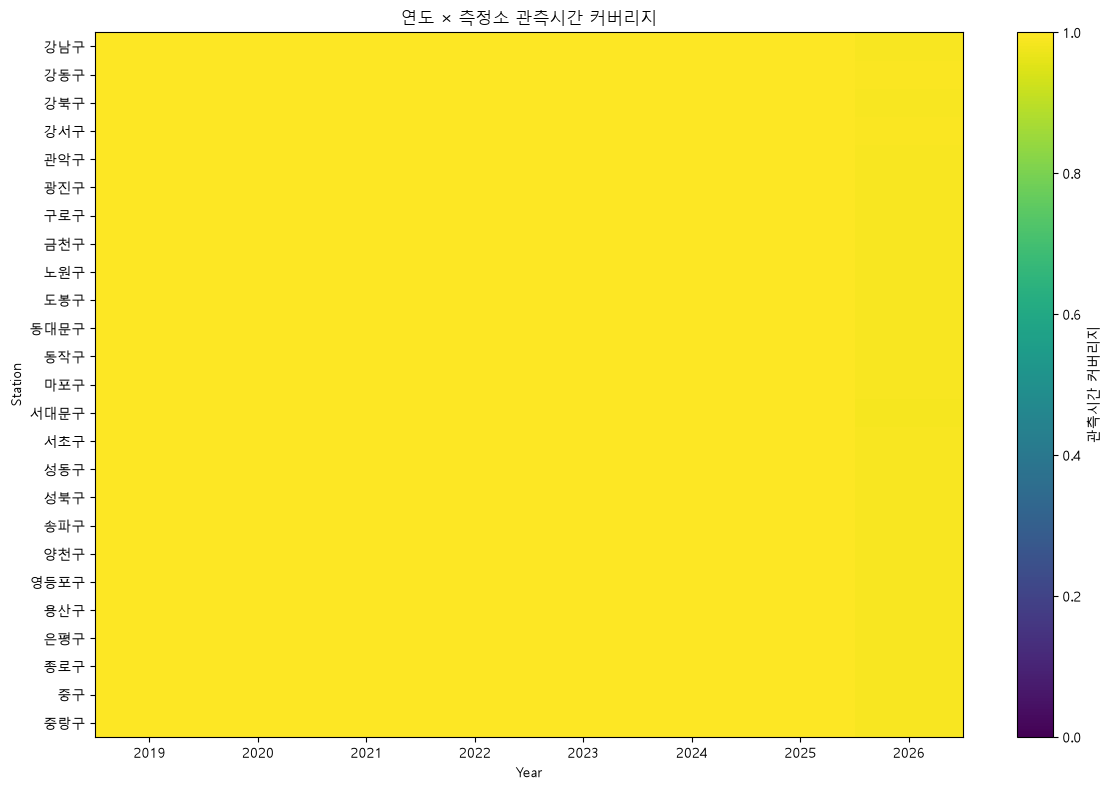

In [7]:
# 연도별 예상 관측시간
def expected_hours_for_year(year, max_dt):
    start = pd.Timestamp(
        year=year,
        month=1,
        day=1,
        hour=0
    )

    if year == 2026:
        end = min(
            max_dt.floor("h"),
            pd.Timestamp(
                "2026-12-31 23:00"
            )
        )
    else:
        end = pd.Timestamp(
            year=year,
            month=12,
            day=31,
            hour=23
        )

    if end < start:
        return 0

    return int(
        (end - start)
        / pd.Timedelta(hours=1)
    ) + 1


max_dt = air["datetime"].max()

station_year_count = (
    air
    .groupby(
        ["year", "station"]
    )
    .size()
    .reset_index(name="observed_hours")
)

station_year_count[
    "expected_hours"
] = station_year_count["year"].map(
    lambda y: expected_hours_for_year(
        int(y),
        max_dt
    )
)

station_year_count[
    "coverage_rate"
] = (
    station_year_count["observed_hours"]
    /
    station_year_count["expected_hours"]
)

coverage_pivot = (
    station_year_count
    .pivot(
        index="station",
        columns="year",
        values="coverage_rate"
    )
)

display(
    station_year_count
    .sort_values("coverage_rate")
    .head(30)
)

plt.figure(
    figsize=(12, max(7, len(coverage_pivot) * 0.32))
)

plt.imshow(
    coverage_pivot.values,
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.colorbar(
    label="관측시간 커버리지"
)

plt.yticks(
    range(len(coverage_pivot.index)),
    coverage_pivot.index
)

plt.xticks(
    range(len(coverage_pivot.columns)),
    coverage_pivot.columns
)

plt.title(
    "연도 × 측정소 관측시간 커버리지"
)

plt.xlabel("Year")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

In [8]:
quality_rows = []

for col in AVAILABLE_POLLUTANTS:
    s = air[col]

    quality_rows.append({
        "pollutant": col,
        "label": POLLUTANTS[col],
        "count": int(s.notna().sum()),
        "missing_rate": float(s.isna().mean()),
        "zero_rate": float((s == 0).mean()),
        "negative_rate_after_clean": float((s < 0).mean()),
        "median": s.median(),
        "mean": s.mean(),
        "p99": s.quantile(.99)
    })

quality_summary = pd.DataFrame(
    quality_rows
)

display(quality_summary)

,pollutant,label,count,missing_rate,zero_rate,negative_rate_after_clean,median,mean,p99
0,pm10_1h,미세먼지 1시간 (㎍/㎥),1661586,0.0188,0.0097,0.0000,29.0000,34.9988,132.0000
1,pm10_24h,미세먼지 24시간 (㎍/㎥),1520831,0.1019,0.0037,0.0000,30.0000,34.5634,115.0000
2,pm25,초미세먼지 (㎍/㎥),1667443,0.0153,0.0073,0.0000,16.0000,19.6728,79.0000
3,o3,오존 (ppm),1672436,0.0124,0.0058,0.0000,0.0275,0.0297,0.0911
4,no2,이산화질소 (ppm),1671073,0.0132,0.0061,0.0000,0.0170,0.0211,0.0640
5,co,일산화탄소 (ppm),1662673,0.0182,0.0068,0.0000,0.4000,0.4420,1.1000
6,so2,아황산가스 (ppm),1665858,0.0163,0.0057,0.0000,0.0030,0.0030,0.0070


In [9]:
# 연도 × 측정소 × 오염물질 결측률
missing_records = []

for col in AVAILABLE_POLLUTANTS:
    temp = (
        air
        .groupby(
            ["year", "station"]
        )[col]
        .apply(
            lambda s: s.isna().mean()
        )
        .reset_index(
            name="missing_rate"
        )
    )

    temp["pollutant"] = col

    missing_records.append(
        temp
    )

missing_by_station_year = pd.concat(
    missing_records,
    ignore_index=True
)

display(
    missing_by_station_year
    .sort_values(
        "missing_rate",
        ascending=False
    )
    .head(40)
)


# 0값이 어디에 몰리는지 확인
zero_records = []

for col in AVAILABLE_POLLUTANTS:
    temp = (
        air
        .assign(
            is_zero=air[col].eq(0)
        )
        .groupby(
            ["year", "station"]
        )["is_zero"]
        .mean()
        .reset_index(
            name="zero_rate"
        )
    )

    temp["pollutant"] = col

    zero_records.append(
        temp
    )

zero_by_station_year = pd.concat(
    zero_records,
    ignore_index=True
)

display(
    zero_by_station_year
    .sort_values(
        "zero_rate",
        ascending=False
    )
    .head(40)
)


latest_2026 = (
    air.loc[
        air["year"] == 2026,
        "datetime"
    ].max()
)

print("2026 마지막 관측시각:", latest_2026)

,year,station,missing_rate,pollutant
376,2026,강동구,1.0000,pm10_24h
377,2026,강북구,1.0000,pm10_24h
383,2026,노원구,1.0000,pm10_24h
393,2026,양천구,1.0000,pm10_24h
392,2026,송파구,1.0000,pm10_24h
399,2026,중랑구,1.0000,pm10_24h
398,2026,중구,1.0000,pm10_24h
397,2026,종로구,1.0000,pm10_24h
396,2026,은평구,1.0000,pm10_24h
395,2026,용산구,1.0000,pm10_24h


,year,station,zero_rate,pollutant
404,2019,관악구,0.1686,pm25
4,2019,관악구,0.1651,pm10_1h
1023,2019,중구,0.1541,co
204,2019,관악구,0.1467,pm10_24h
12,2019,마포구,0.1418,pm10_1h
624,2019,중랑구,0.1324,o3
1024,2019,중랑구,0.1203,co
1224,2019,중랑구,0.1201,so2
24,2019,중랑구,0.1194,pm10_1h
812,2019,마포구,0.1185,no2


2026 마지막 관측시각: 2026-09-25 16:00:00


In [10]:
quality_conclusion_lines = []

if (
    len(year_coverage)
    and
    year_coverage["station_count"].eq(25).all()
):
    quality_conclusion_lines.append(
        "- **측정소 구성:** 분석에 포함된 모든 연도에서 25개 측정소가 확인되었다."
    )
else:
    bad = year_coverage[
        year_coverage["station_count"] != 25
    ]
    quality_conclusion_lines.append(
        "- **측정소 구성:** 일부 연도에서 25개 측정소가 모두 존재하지 않는다. 해당 연도는 지역 비교 시 주의가 필요하다."
    )

worst_cov = station_year_count.loc[
    station_year_count["coverage_rate"].idxmin()
]

quality_conclusion_lines.append(
    f"- **관측 커버리지:** 가장 낮은 연도×측정소 조합은 "
    f"`{int(worst_cov['year'])} / {worst_cov['station']}`이며 "
    f"커버리지는 {worst_cov['coverage_rate']:.1%}이다."
)

max_missing = missing_by_station_year.loc[
    missing_by_station_year["missing_rate"].idxmax()
]

quality_conclusion_lines.append(
    f"- **결측:** 가장 높은 결측률은 "
    f"`{int(max_missing['year'])} / {max_missing['station']} / "
    f"{POLLUTANTS[max_missing['pollutant']]}`의 "
    f"{max_missing['missing_rate']:.1%}이다."
)

max_zero = zero_by_station_year.loc[
    zero_by_station_year["zero_rate"].idxmax()
]

quality_conclusion_lines.append(
    f"- **0값:** 가장 높은 0값 비율은 "
    f"`{int(max_zero['year'])} / {max_zero['station']} / "
    f"{POLLUTANTS[max_zero['pollutant']]}`의 "
    f"{max_zero['zero_rate']:.1%}이다. "
    f"0값을 결측으로 바꿀지는 원자료 정의 확인 후 결정해야 한다."
)

if pd.notna(latest_2026):
    quality_conclusion_lines.append(
        f"- **2026 자료 범위:** {latest_2026:%Y-%m-%d %H:%M}까지 존재한다."
    )

display(
    Markdown(
        "### A. 데이터 품질 결론\n\n"
        + "\n".join(
            quality_conclusion_lines
        )
    )
)

### A. 데이터 품질 결론

- **측정소 구성:** 분석에 포함된 모든 연도에서 25개 측정소가 확인되었다.
- **관측 커버리지:** 가장 낮은 연도×측정소 조합은 `2026 / 서대문구`이며 커버리지는 98.5%이다.
- **결측:** 가장 높은 결측률은 `2026 / 강남구 / 미세먼지 24시간 (㎍/㎥)`의 100.0%이다.
- **0값:** 가장 높은 0값 비율은 `2019 / 관악구 / 초미세먼지 (㎍/㎥)`의 16.9%이다. 0값을 결측으로 바꿀지는 원자료 정의 확인 후 결정해야 한다.
- **2026 자료 범위:** 2026-09-25 16:00까지 존재한다.

# 6. 공통 집계 테이블

장기 추세와 계절성은 특정 측정소 하나에 끌려가지 않도록 먼저 **측정소별 평균을 만든 뒤 서울 전체 평균**을 계산한다.


In [11]:
# 월별 측정소 평균
station_monthly = (
    air
    .groupby(
        [
            "station",
            pd.Grouper(
                key="datetime",
                freq="MS"
            )
        ],
        as_index=False
    )[AVAILABLE_POLLUTANTS]
    .mean()
)

station_monthly["year"] = (
    station_monthly["datetime"]
    .dt.year
)

station_monthly["month"] = (
    station_monthly["datetime"]
    .dt.month
)


# 서울 월평균 = 월별 측정소 평균의 평균
city_monthly = (
    station_monthly
    .groupby(
        "datetime",
        as_index=False
    )[AVAILABLE_POLLUTANTS]
    .mean()
)

city_monthly["year"] = (
    city_monthly["datetime"]
    .dt.year
)

city_monthly["month"] = (
    city_monthly["datetime"]
    .dt.month
)


# 서울 시간대 profile
station_hour_profile = (
    air.loc[
        air["year"].between(
            2019,
            2025
        )
    ]
    .groupby(
        ["station", "hour"],
        as_index=False
    )[AVAILABLE_POLLUTANTS]
    .mean()
)

city_hour_profile = (
    station_hour_profile
    .groupby(
        "hour",
        as_index=False
    )[AVAILABLE_POLLUTANTS]
    .mean()
)

print("station_monthly:", station_monthly.shape)
print("city_monthly:", city_monthly.shape)
print("city_hour_profile:", city_hour_profile.shape)

station_monthly: (2325, 11)
city_monthly: (93, 10)
city_hour_profile: (24, 8)


# 7. B. 장기 추세

장기 추세는 **2019~2025 완전연도**를 기준으로 판단한다.

2026년은 부분연도이므로 연간평균을 직접 비교하지 않고:

```text
2026-01-01 ~ 2026 마지막 관측시각
vs
2019~2025 각 연도의 동일한 월·일·시간 범위
```

로 비교한다.


,year,pm10_1h,pm10_24h,pm25,o3,no2,co,so2
0,2019,39.9978,39.3774,24.0868,0.0242,0.0273,0.5102,0.0038
1,2020,35.0346,34.5340,20.6026,0.0250,0.0237,0.4711,0.0031
2,2021,38.2164,37.0129,19.8587,0.0278,0.0236,0.4630,0.0031
3,2022,32.8740,32.3422,18.4106,0.0293,0.0209,0.4368,0.0029
4,2023,37.9175,36.7421,19.8127,0.0309,0.0205,0.4520,0.0028
5,2024,31.2738,30.7830,17.5607,0.0333,0.0188,0.4135,0.0027
6,2025,31.8759,31.2548,18.4766,0.0326,0.0176,0.4054,0.0027


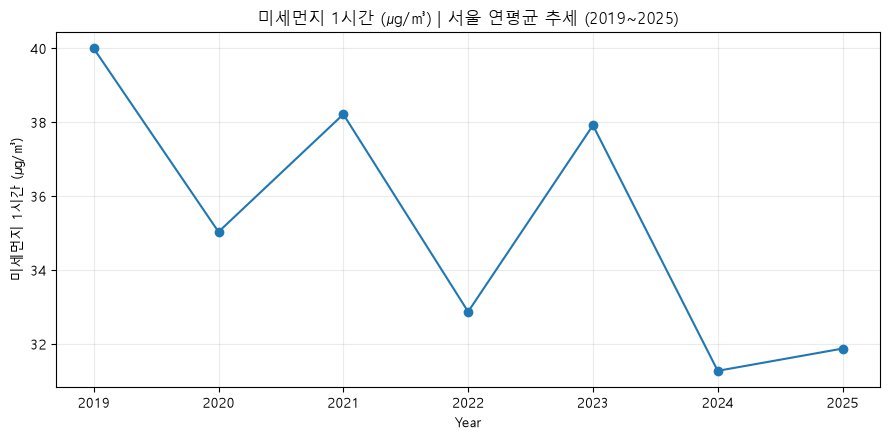

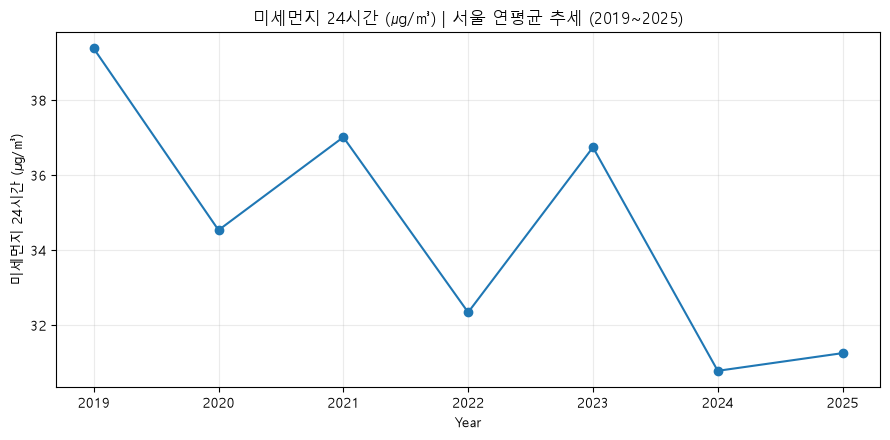

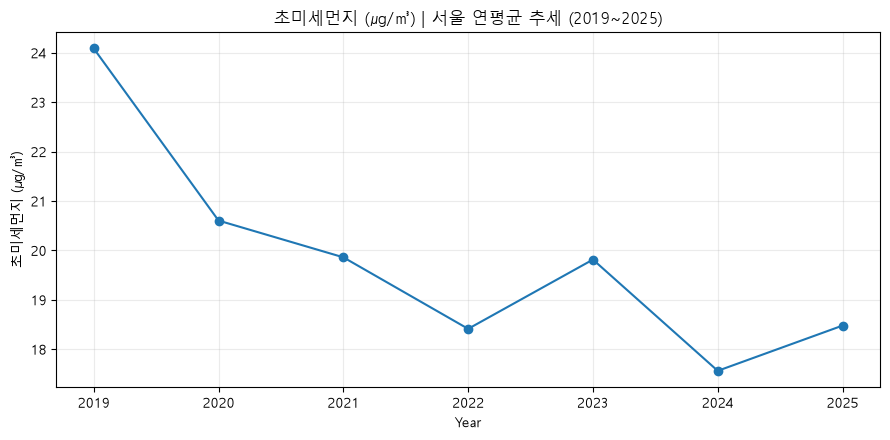

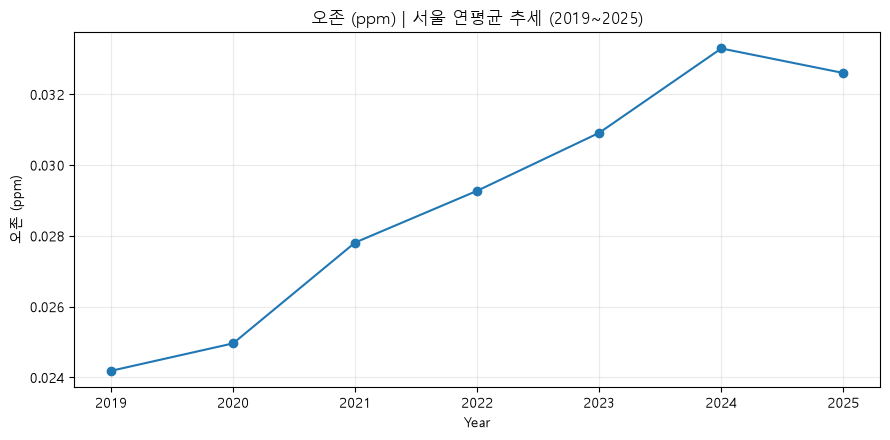

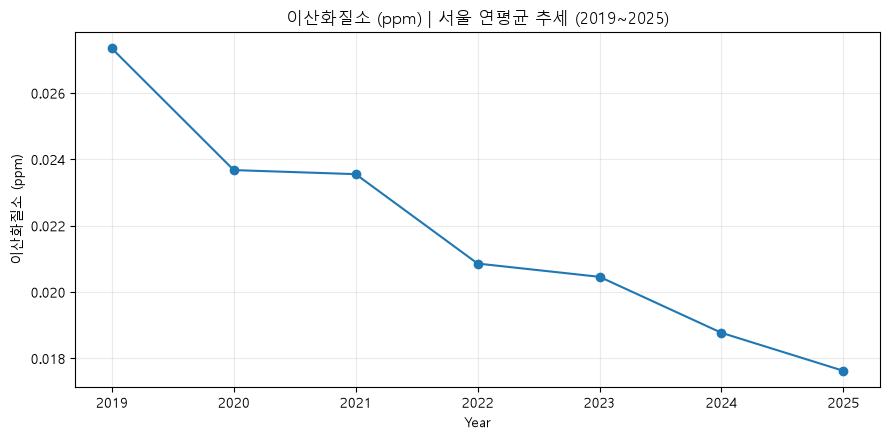

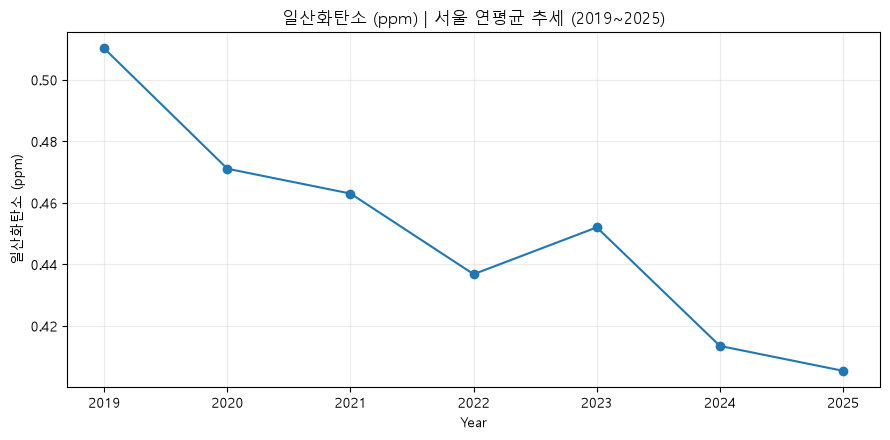

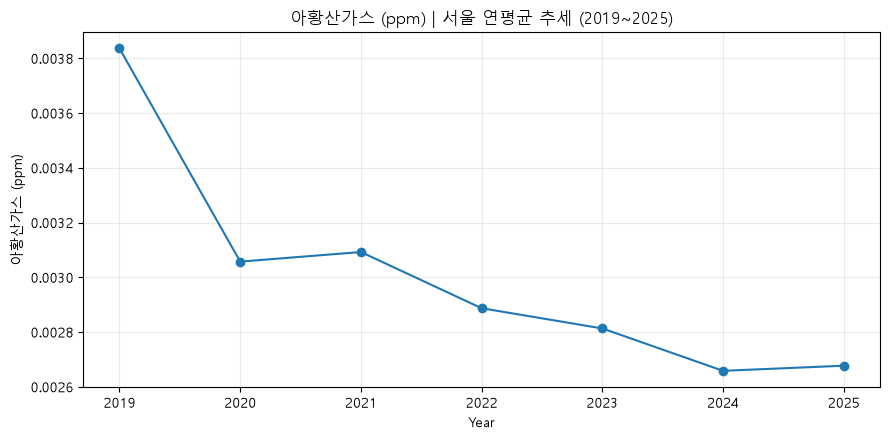

In [12]:
complete_years = list(
    range(2019, 2026)
)

annual_complete = (
    city_monthly.loc[
        city_monthly["year"].isin(
            complete_years
        )
    ]
    .groupby(
        "year",
        as_index=False
    )[AVAILABLE_POLLUTANTS]
    .mean()
)

display(annual_complete)


for pollutant in AVAILABLE_POLLUTANTS:
    plt.figure(
        figsize=(9, 4.5)
    )

    plt.plot(
        annual_complete["year"],
        annual_complete[pollutant],
        marker="o"
    )

    plt.title(
        f"{POLLUTANTS[pollutant]} | "
        "서울 연평균 추세 (2019~2025)"
    )

    plt.xlabel("Year")
    plt.ylabel(
        POLLUTANTS[pollutant]
    )

    plt.xticks(
        complete_years
    )

    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [13]:
# 장기 추세 기울기
trend_rows = []

for pollutant in AVAILABLE_POLLUTANTS:
    temp = annual_complete[
        ["year", pollutant]
    ].dropna()

    if len(temp) < 3:
        continue

    x = temp["year"].to_numpy(
        dtype=float
    )

    y = temp[pollutant].to_numpy(
        dtype=float
    )

    slope, intercept = np.polyfit(
        x,
        y,
        1
    )

    mean_value = np.nanmean(y)

    slope_pct_per_year = (
        slope / mean_value * 100
        if mean_value != 0
        else np.nan
    )

    first_value = y[0]
    last_value = y[-1]

    total_change_pct = (
        (last_value - first_value)
        / first_value
        * 100
        if first_value != 0
        else np.nan
    )

    # 해석용 보수적 threshold
    if slope_pct_per_year > 1:
        direction = "상승 경향"
    elif slope_pct_per_year < -1:
        direction = "하락 경향"
    else:
        direction = "뚜렷한 상승·하락 없음"

    trend_rows.append({
        "pollutant": pollutant,
        "label": POLLUTANTS[pollutant],
        "slope_per_year": slope,
        "slope_pct_per_year": slope_pct_per_year,
        "2019_to_2025_change_pct": total_change_pct,
        "direction": direction
    })

trend_summary = pd.DataFrame(
    trend_rows
)

display(trend_summary)

,pollutant,label,slope_per_year,slope_pct_per_year,2019_to_2025_change_pct,direction
0,pm10_1h,미세먼지 1시간 (㎍/㎥),-1.1495,-3.2552,-20.3059,하락 경향
1,pm10_24h,미세먼지 24시간 (㎍/㎥),-1.1479,-3.3197,-20.6276,하락 경향
2,pm25,초미세먼지 (㎍/㎥),-0.8200,-4.1352,-23.2917,하락 경향
3,o3,오존 (ppm),0.0016,5.5433,34.7995,상승 경향
4,no2,이산화질소 (ppm),-0.0015,-6.9044,-35.5388,하락 경향
5,co,일산화탄소 (ppm),-0.0157,-3.4932,-20.5341,하락 경향
6,so2,아황산가스 (ppm),-0.0002,-5.4167,-30.2166,하락 경향


In [14]:
# 2026 동일기간 비교
max_2026 = air.loc[
    air["year"] == 2026,
    "datetime"
].max()

ytd_rows = []

if pd.notna(max_2026):
    end_month = int(max_2026.month)
    end_day = int(max_2026.day)
    end_hour = int(max_2026.hour)

    for year in range(2019, 2027):
        start = pd.Timestamp(
            year=year,
            month=1,
            day=1,
            hour=0
        )

        try:
            end = pd.Timestamp(
                year=year,
                month=end_month,
                day=end_day,
                hour=end_hour
            )
        except ValueError:
            # 윤년 날짜 문제 방지
            end = (
                pd.Timestamp(
                    year=year,
                    month=end_month,
                    day=1
                )
                + pd.offsets.MonthEnd(0)
            ).replace(
                hour=end_hour
            )

        temp = air[
            (air["datetime"] >= start)
            &
            (air["datetime"] <= end)
        ]

        # 측정소별 평균 → 서울 평균
        station_means = (
            temp
            .groupby("station")[
                AVAILABLE_POLLUTANTS
            ]
            .mean()
        )

        city_means = station_means.mean()

        row = {
            "year": year,
            "window_end": end
        }

        for pollutant in AVAILABLE_POLLUTANTS:
            row[pollutant] = city_means[
                pollutant
            ]

        ytd_rows.append(row)

ytd_summary = pd.DataFrame(
    ytd_rows
)

display(ytd_summary)


ytd_compare_rows = []

if len(ytd_summary):
    hist = ytd_summary[
        ytd_summary["year"].between(
            2019,
            2025
        )
    ]

    now = ytd_summary[
        ytd_summary["year"] == 2026
    ]

    if len(now):
        for pollutant in AVAILABLE_POLLUTANTS:
            hist_mean = hist[
                pollutant
            ].mean()

            value_2026 = now[
                pollutant
            ].iloc[0]

            diff_pct = (
                (value_2026 - hist_mean)
                / hist_mean
                * 100
                if hist_mean != 0
                else np.nan
            )

            ytd_compare_rows.append({
                "pollutant": pollutant,
                "label": POLLUTANTS[pollutant],
                "historical_same_period_mean_2019_2025": hist_mean,
                "value_2026_same_period": value_2026,
                "2026_vs_history_pct": diff_pct
            })

ytd_compare = pd.DataFrame(
    ytd_compare_rows
)

display(ytd_compare)

,year,window_end,pm10_1h,pm10_24h,pm25,o3,no2,co,so2
0,2019,2019-09-25 16:00:00,41.7104,40.9170,25.5742,0.0277,0.0264,0.4991,0.0041
1,2020,2020-09-25 16:00:00,34.0237,33.6477,20.0664,0.0276,0.0220,0.4474,0.0029
2,2021,2021-09-25 16:00:00,39.2347,37.8939,19.7534,0.0313,0.0221,0.4414,0.0031
3,2022,2022-09-25 16:00:00,32.4216,31.8668,18.2577,0.0328,0.0191,0.4165,0.0029
4,2023,2023-09-25 16:00:00,40.3453,38.8867,20.4876,0.0340,0.0193,0.4361,0.0029
5,2024,2024-09-25 16:00:00,32.5495,31.8919,18.1872,0.0370,0.0180,0.4029,0.0026
6,2025,2025-09-25 16:00:00,32.8609,32.1276,19.1829,0.0362,0.0167,0.3935,0.0027
7,2026,2026-09-25 16:00:00,31.8086,NaN,18.3236,0.0363,0.0153,0.3697,0.0025


,pollutant,label,historical_same_period_mean_2019_2025,value_2026_same_period,2026_vs_history_pct
0,pm10_1h,미세먼지 1시간 (㎍/㎥),36.1637,31.8086,-12.0429
1,pm10_24h,미세먼지 24시간 (㎍/㎥),35.3188,NaN,NaN
2,pm25,초미세먼지 (㎍/㎥),20.2156,18.3236,-9.3592
3,o3,오존 (ppm),0.0324,0.0363,12.2342
4,no2,이산화질소 (ppm),0.0205,0.0153,-25.2557
5,co,일산화탄소 (ppm),0.4338,0.3697,-14.7726
6,so2,아황산가스 (ppm),0.0030,0.0025,-16.4406


In [15]:
trend_lines = []

for _, row in trend_summary.iterrows():
    trend_lines.append(
        f"- **{row['label']}**: "
        f"2019~2025 연평균 기준 `{row['direction']}`. "
        f"연평균 대비 기울기는 약 "
        f"{row['slope_pct_per_year']:+.2f}%/년, "
        f"2019→2025 변화는 "
        f"{row['2019_to_2025_change_pct']:+.1f}%."
    )

if len(ytd_compare):
    trend_lines.append(
        "\n**2026 동일기간 비교**"
    )

    for _, row in ytd_compare.iterrows():
        trend_lines.append(
            f"- {row['label']}: "
            f"2019~2025 동일기간 평균 대비 "
            f"{row['2026_vs_history_pct']:+.1f}%."
        )

display(
    Markdown(
        "### B. 장기 추세 결론\n\n"
        + "\n".join(trend_lines)
    )
)

### B. 장기 추세 결론

- **미세먼지 1시간 (㎍/㎥)**: 2019~2025 연평균 기준 `하락 경향`. 연평균 대비 기울기는 약 -3.26%/년, 2019→2025 변화는 -20.3%.
- **미세먼지 24시간 (㎍/㎥)**: 2019~2025 연평균 기준 `하락 경향`. 연평균 대비 기울기는 약 -3.32%/년, 2019→2025 변화는 -20.6%.
- **초미세먼지 (㎍/㎥)**: 2019~2025 연평균 기준 `하락 경향`. 연평균 대비 기울기는 약 -4.14%/년, 2019→2025 변화는 -23.3%.
- **오존 (ppm)**: 2019~2025 연평균 기준 `상승 경향`. 연평균 대비 기울기는 약 +5.54%/년, 2019→2025 변화는 +34.8%.
- **이산화질소 (ppm)**: 2019~2025 연평균 기준 `하락 경향`. 연평균 대비 기울기는 약 -6.90%/년, 2019→2025 변화는 -35.5%.
- **일산화탄소 (ppm)**: 2019~2025 연평균 기준 `하락 경향`. 연평균 대비 기울기는 약 -3.49%/년, 2019→2025 변화는 -20.5%.
- **아황산가스 (ppm)**: 2019~2025 연평균 기준 `하락 경향`. 연평균 대비 기울기는 약 -5.42%/년, 2019→2025 변화는 -30.2%.

**2026 동일기간 비교**
- 미세먼지 1시간 (㎍/㎥): 2019~2025 동일기간 평균 대비 -12.0%.
- 미세먼지 24시간 (㎍/㎥): 2019~2025 동일기간 평균 대비 +nan%.
- 초미세먼지 (㎍/㎥): 2019~2025 동일기간 평균 대비 -9.4%.
- 오존 (ppm): 2019~2025 동일기간 평균 대비 +12.2%.
- 이산화질소 (ppm): 2019~2025 동일기간 평균 대비 -25.3%.
- 일산화탄소 (ppm): 2019~2025 동일기간 평균 대비 -14.8%.
- 아황산가스 (ppm): 2019~2025 동일기간 평균 대비 -16.4%.

# 8. C. 계절성

계절성은 2026년 부분연도의 영향을 피하기 위해 **2019~2025 완전연도**로 계산한다.

오염물질별로:

- 가장 높은 달
- 가장 낮은 달
- 월별 변동폭
- 평균 대비 계절 변동 정도

를 계산한다.


,month,pm10_1h,pm10_24h,pm25,o3,no2,co,so2
0,1,44.8561,43.2784,27.7405,0.0158,0.0314,0.6267,0.0036
1,2,42.7669,41.4926,27.3569,0.0224,0.0285,0.5553,0.0033
2,3,55.9518,53.3440,29.2129,0.0305,0.0266,0.4989,0.0032
3,4,46.2827,44.9923,20.8646,0.0384,0.0214,0.4168,0.0030
4,5,40.3637,39.5113,19.5912,0.0420,0.0184,0.3906,0.0031
5,6,29.5056,29.6035,17.6619,0.0442,0.0163,0.3781,0.0029
6,7,23.0750,23.2171,14.9773,0.0353,0.0140,0.3464,0.0027
7,8,21.9050,22.0488,13.7547,0.0318,0.0136,0.3406,0.0027
8,9,18.3473,18.3110,9.8894,0.0299,0.0144,0.3494,0.0026
9,10,25.7053,25.5626,13.4515,0.0235,0.0203,0.4158,0.0028


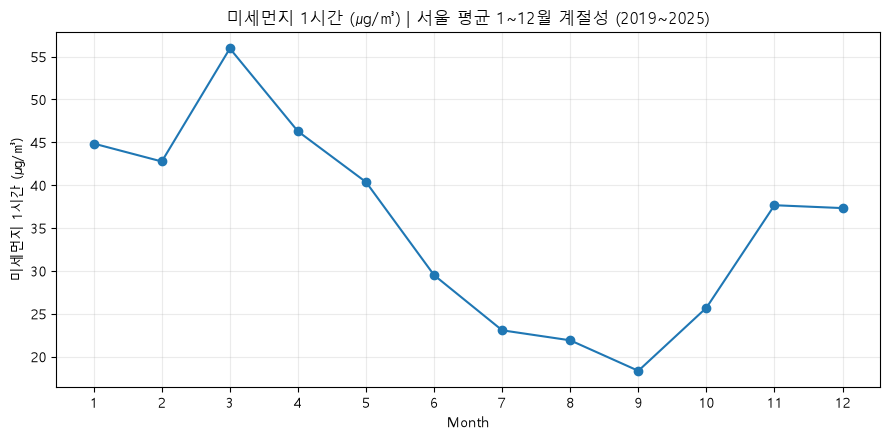

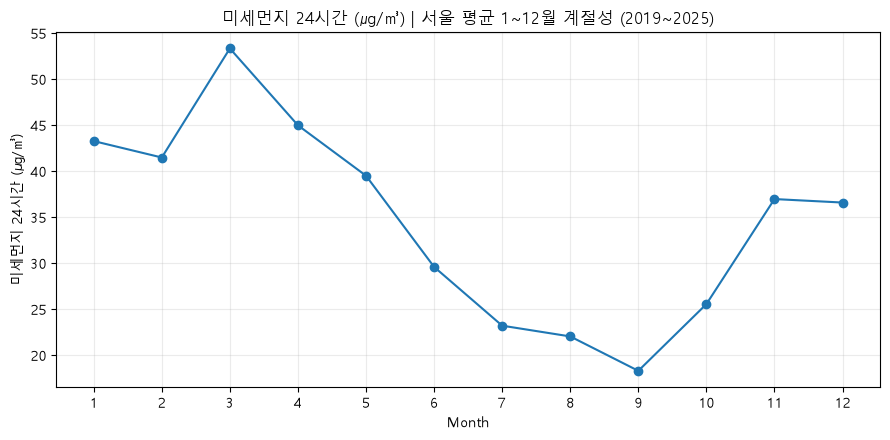

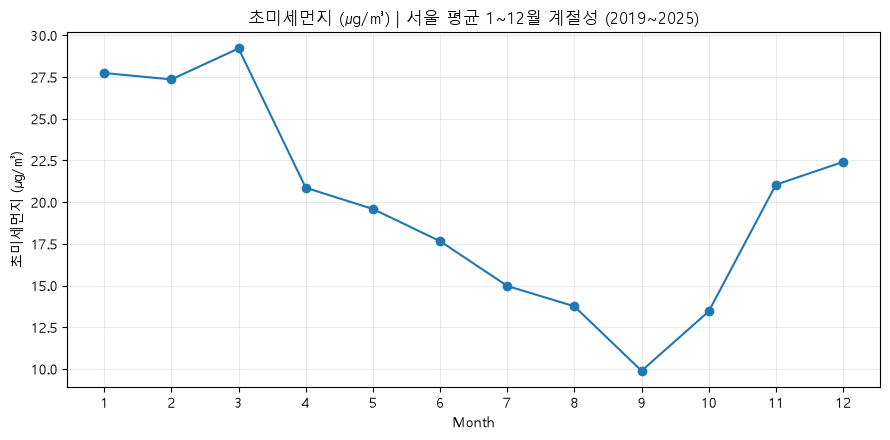

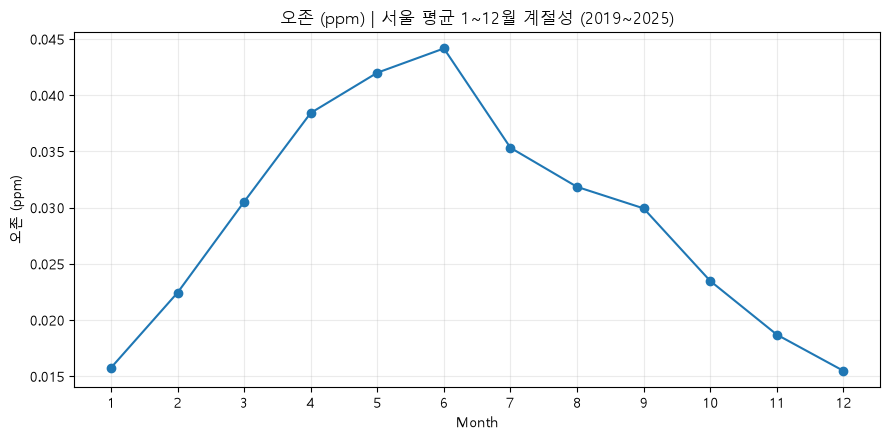

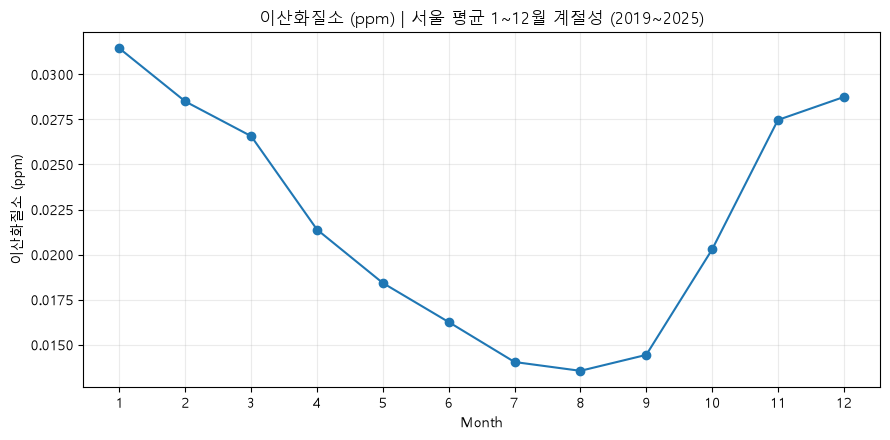

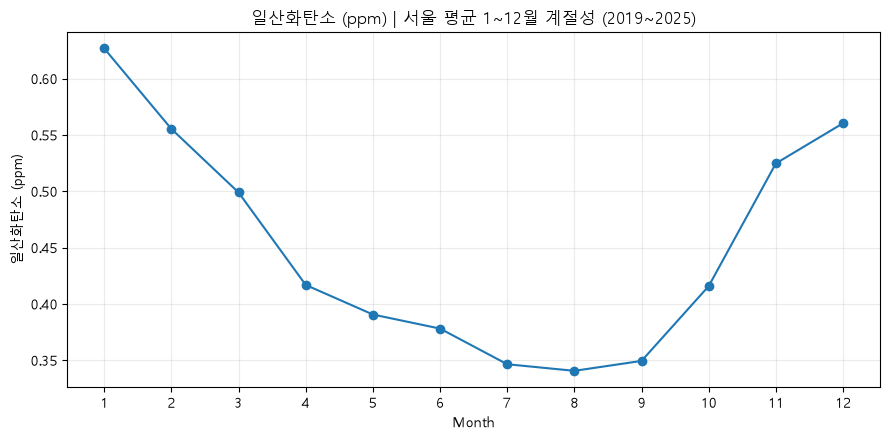

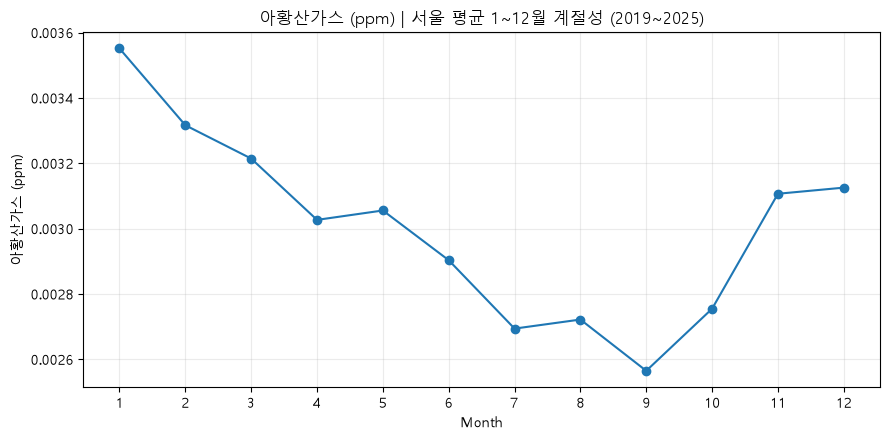

In [16]:
season_source = city_monthly[
    city_monthly["year"].between(
        2019,
        2025
    )
]

season_profile = (
    season_source
    .groupby(
        "month",
        as_index=False
    )[AVAILABLE_POLLUTANTS]
    .mean()
)

display(season_profile)

for pollutant in AVAILABLE_POLLUTANTS:
    plt.figure(
        figsize=(9, 4.5)
    )

    plt.plot(
        season_profile["month"],
        season_profile[pollutant],
        marker="o"
    )

    plt.title(
        f"{POLLUTANTS[pollutant]} | "
        "서울 평균 1~12월 계절성 (2019~2025)"
    )

    plt.xlabel("Month")
    plt.ylabel(
        POLLUTANTS[pollutant]
    )

    plt.xticks(
        range(1, 13)
    )

    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [17]:
seasonality_rows = []

for pollutant in AVAILABLE_POLLUTANTS:
    s = (
        season_profile
        .set_index("month")[pollutant]
        .dropna()
    )

    if len(s) == 0:
        continue

    peak_month = int(
        s.idxmax()
    )

    low_month = int(
        s.idxmin()
    )

    peak = s.max()
    low = s.min()
    mean = s.mean()

    range_pct = (
        (peak - low)
        / mean
        * 100
        if mean != 0
        else np.nan
    )

    cv = (
        s.std(ddof=0)
        / mean
        if mean != 0
        else np.nan
    )

    seasonality_rows.append({
        "pollutant": pollutant,
        "label": POLLUTANTS[pollutant],
        "peak_month": peak_month,
        "low_month": low_month,
        "peak_value": peak,
        "low_value": low,
        "seasonal_range_pct_of_mean": range_pct,
        "month_cv": cv
    })

seasonality_summary = pd.DataFrame(
    seasonality_rows
)

display(
    seasonality_summary
    .sort_values(
        "month_cv",
        ascending=False
    )
)

,pollutant,label,peak_month,low_month,peak_value,low_value,seasonal_range_pct_of_mean,month_cv
3,o3,오존 (ppm),6,12,0.0442,0.0155,98.8626,0.3266
0,pm10_1h,미세먼지 1시간 (㎍/㎥),3,9,55.9518,18.3473,106.4897,0.3136
2,pm25,초미세먼지 (㎍/㎥),3,9,29.2129,9.8894,97.4467,0.2988
1,pm10_24h,미세먼지 24시간 (㎍/㎥),3,9,53.3440,18.3110,101.3160,0.2981
4,no2,이산화질소 (ppm),1,8,0.0314,0.0136,82.1887,0.2869
5,co,일산화탄소 (ppm),1,8,0.6267,0.3406,63.5407,0.2090
6,so2,아황산가스 (ppm),1,9,0.0036,0.0026,32.8557,0.0917


In [18]:
# 측정소마다 계절성 크기가 다른지
station_season = (
    station_monthly[
        station_monthly["year"].between(
            2019,
            2025
        )
    ]
    .groupby(
        ["station", "month"],
        as_index=False
    )[AVAILABLE_POLLUTANTS]
    .mean()
)

station_season_rows = []

for station in stations:
    part = station_season[
        station_season["station"]
        == station
    ]

    for pollutant in AVAILABLE_POLLUTANTS:
        s = part[
            pollutant
        ].dropna()

        if len(s) == 0:
            continue

        mean = s.mean()

        cv = (
            s.std(ddof=0)
            / mean
            if mean != 0
            else np.nan
        )

        station_season_rows.append({
            "station": station,
            "pollutant": pollutant,
            "month_cv": cv
        })

station_seasonality = pd.DataFrame(
    station_season_rows
)

seasonality_by_pollutant = (
    station_seasonality
    .groupby("pollutant")["month_cv"]
    .agg(
        median_station_month_cv="median",
        min_station_month_cv="min",
        max_station_month_cv="max"
    )
    .reset_index()
)

display(seasonality_by_pollutant)

,pollutant,median_station_month_cv,min_station_month_cv,max_station_month_cv
0,co,0.2127,0.1323,0.2529
1,no2,0.3007,0.2212,0.3703
2,o3,0.3327,0.2758,0.3619
3,pm10_1h,0.3083,0.2848,0.3731
4,pm10_24h,0.2919,0.2699,0.3548
5,pm25,0.3014,0.2598,0.3613
6,so2,0.0997,0.0489,0.1964


In [19]:
season_lines = []

for _, row in seasonality_summary.iterrows():
    season_lines.append(
        f"- **{row['label']}**: "
        f"평균적으로 {int(row['peak_month'])}월이 가장 높고 "
        f"{int(row['low_month'])}월이 가장 낮다. "
        f"월별 최대-최소 폭은 전체 평균의 "
        f"약 {row['seasonal_range_pct_of_mean']:.1f}%."
    )

display(
    Markdown(
        "### C. 계절성 결론\n\n"
        + "\n".join(season_lines)
    )
)

### C. 계절성 결론

- **미세먼지 1시간 (㎍/㎥)**: 평균적으로 3월이 가장 높고 9월이 가장 낮다. 월별 최대-최소 폭은 전체 평균의 약 106.5%.
- **미세먼지 24시간 (㎍/㎥)**: 평균적으로 3월이 가장 높고 9월이 가장 낮다. 월별 최대-최소 폭은 전체 평균의 약 101.3%.
- **초미세먼지 (㎍/㎥)**: 평균적으로 3월이 가장 높고 9월이 가장 낮다. 월별 최대-최소 폭은 전체 평균의 약 97.4%.
- **오존 (ppm)**: 평균적으로 6월이 가장 높고 12월이 가장 낮다. 월별 최대-최소 폭은 전체 평균의 약 98.9%.
- **이산화질소 (ppm)**: 평균적으로 1월이 가장 높고 8월이 가장 낮다. 월별 최대-최소 폭은 전체 평균의 약 82.2%.
- **일산화탄소 (ppm)**: 평균적으로 1월이 가장 높고 8월이 가장 낮다. 월별 최대-최소 폭은 전체 평균의 약 63.5%.
- **아황산가스 (ppm)**: 평균적으로 1월이 가장 높고 9월이 가장 낮다. 월별 최대-최소 폭은 전체 평균의 약 32.9%.

# 9. D. 시간대 패턴

2019~2025 완전연도에서 각 측정소의 시간대 평균을 구한 뒤 서울 평균을 만든다.

오염물질별로:

- 가장 높은 시간
- 가장 낮은 시간
- 24시간 변동폭
- 평균 대비 시간대 변동 정도

를 계산한다.


,hour,pm10_1h,pm10_24h,pm25,o3,no2,co,so2
0,0,34.3548,34.9088,19.7693,0.0238,0.0242,0.4763,0.0030
1,1,34.7556,34.6237,20.1405,0.0234,0.0229,0.4721,0.0029
2,2,33.4985,34.3275,19.5196,0.0234,0.0212,0.4652,0.0029
3,3,33.6934,34.0175,19.8503,0.0231,0.0200,0.4566,0.0029
4,4,32.6531,33.6717,19.2505,0.0225,0.0193,0.4495,0.0028
5,5,33.0271,33.3276,19.6056,0.0213,0.0196,0.4488,0.0028
6,6,32.4211,33.0805,19.1193,0.0189,0.0218,0.4577,0.0028
7,7,33.4095,32.9163,19.5825,0.0163,0.0251,0.4739,0.0029
8,8,33.5690,32.9125,19.1744,0.0163,0.0268,0.4941,0.0029
9,9,35.7183,33.1774,19.9559,0.0191,0.0263,0.5058,0.0030


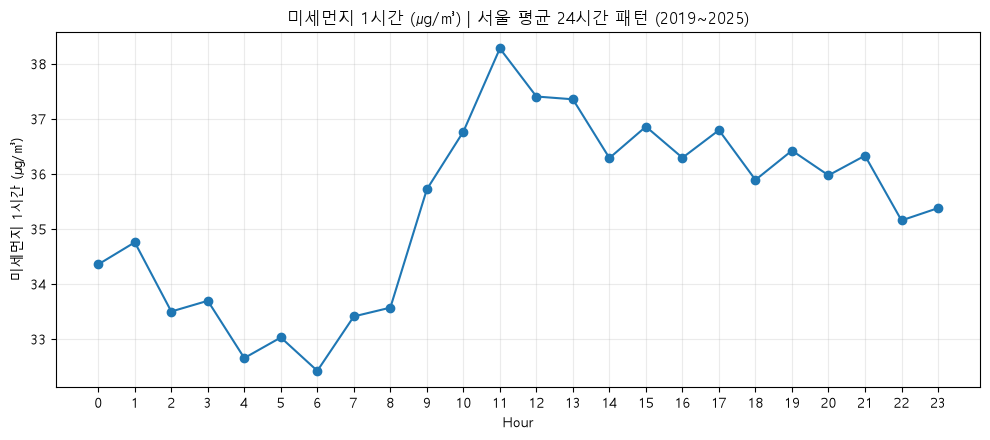

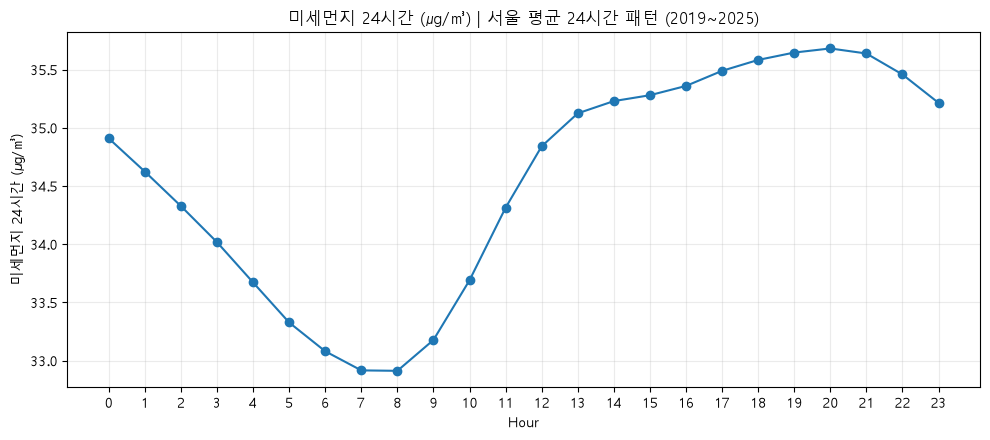

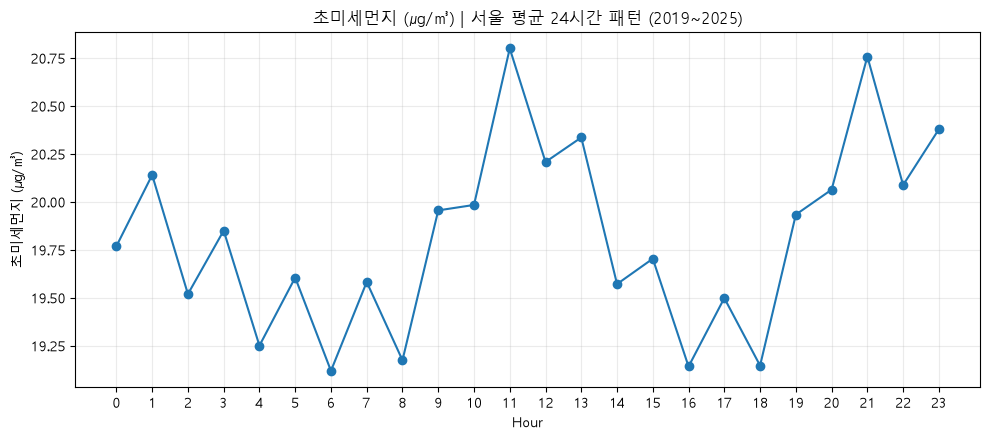

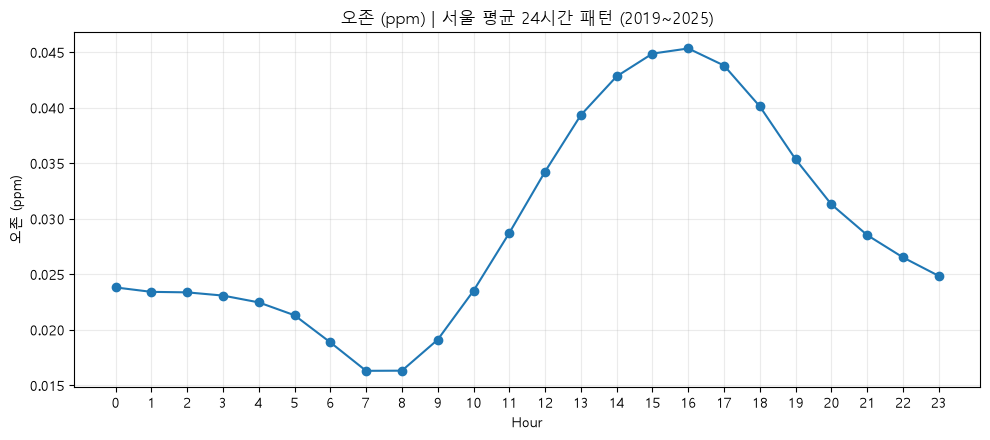

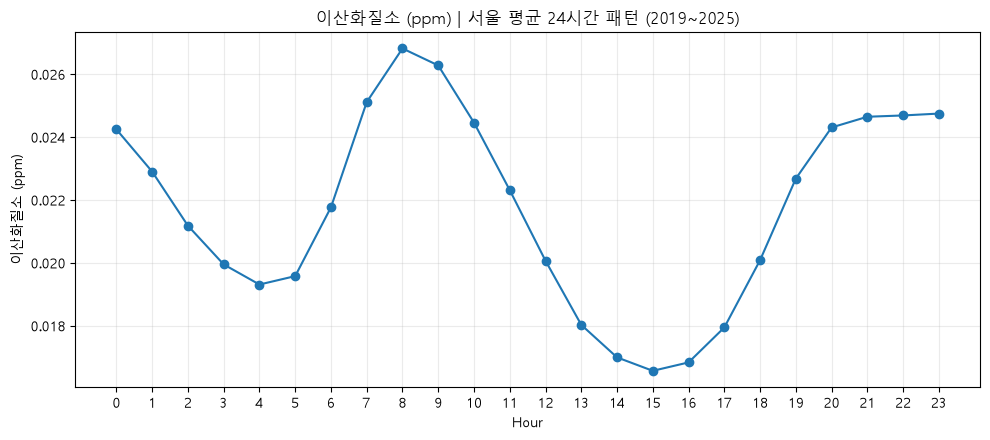

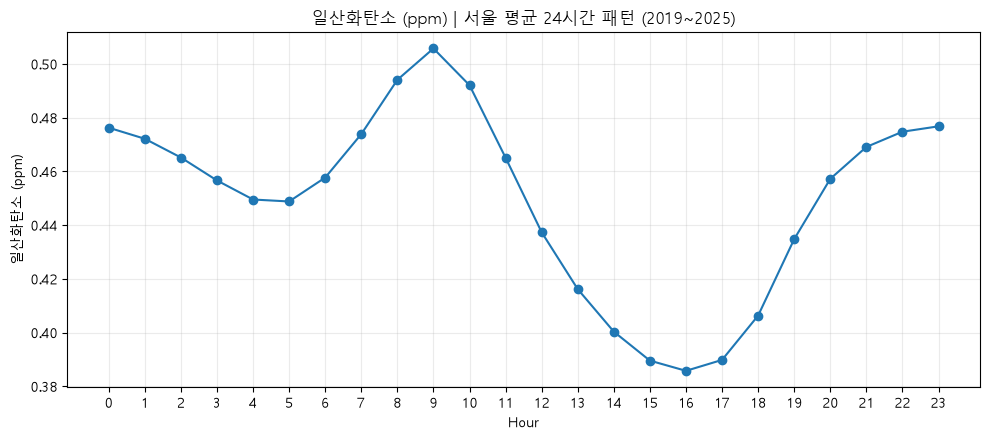

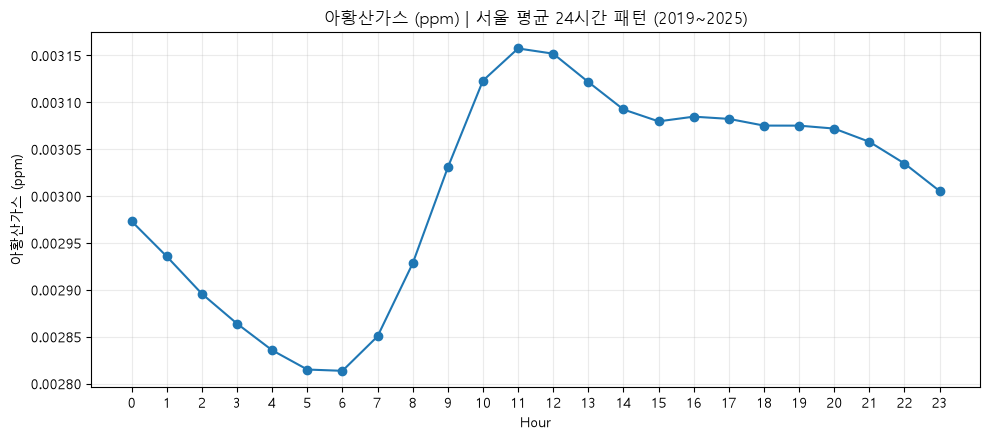

In [20]:
display(city_hour_profile)

for pollutant in AVAILABLE_POLLUTANTS:
    plt.figure(
        figsize=(10, 4.5)
    )

    plt.plot(
        city_hour_profile["hour"],
        city_hour_profile[pollutant],
        marker="o"
    )

    plt.title(
        f"{POLLUTANTS[pollutant]} | "
        "서울 평균 24시간 패턴 (2019~2025)"
    )

    plt.xlabel("Hour")
    plt.ylabel(
        POLLUTANTS[pollutant]
    )

    plt.xticks(
        range(24)
    )

    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [21]:
diurnal_rows = []

for pollutant in AVAILABLE_POLLUTANTS:
    s = (
        city_hour_profile
        .set_index("hour")[pollutant]
        .dropna()
    )

    if len(s) == 0:
        continue

    peak_hour = int(
        s.idxmax()
    )

    low_hour = int(
        s.idxmin()
    )

    mean = s.mean()

    range_pct = (
        (s.max() - s.min())
        / mean
        * 100
        if mean != 0
        else np.nan
    )

    cv = (
        s.std(ddof=0)
        / mean
        if mean != 0
        else np.nan
    )

    diurnal_rows.append({
        "pollutant": pollutant,
        "label": POLLUTANTS[pollutant],
        "peak_hour": peak_hour,
        "low_hour": low_hour,
        "diurnal_range_pct_of_mean": range_pct,
        "hour_cv": cv
    })

diurnal_summary = pd.DataFrame(
    diurnal_rows
)

display(
    diurnal_summary
    .sort_values(
        "hour_cv",
        ascending=False
    )
)

,pollutant,label,peak_hour,low_hour,diurnal_range_pct_of_mean,hour_cv
3,o3,오존 (ppm),16,7,99.9019,0.3169
4,no2,이산화질소 (ppm),8,15,47.1761,0.1418
5,co,일산화탄소 (ppm),9,16,26.6808,0.0762
0,pm10_1h,미세먼지 1시간 (㎍/㎥),11,6,16.5685,0.0461
6,so2,아황산가스 (ppm),11,6,11.4353,0.0363
1,pm10_24h,미세먼지 24시간 (㎍/㎥),20,8,8.0113,0.0276
2,pm25,초미세먼지 (㎍/㎥),11,6,8.4826,0.0239


In [22]:
if (
    "o3" in AVAILABLE_POLLUTANTS
    and
    "no2" in AVAILABLE_POLLUTANTS
):
    o3_no2_hour_corr = (
        city_hour_profile[
            ["o3", "no2"]
        ]
        .corr()
        .iloc[0, 1]
    )

    print(
        "O3 vs NO2 24시간 profile 상관:",
        round(
            o3_no2_hour_corr,
            4
        )
    )
else:
    o3_no2_hour_corr = np.nan

O3 vs NO2 24시간 profile 상관: -0.7336


In [23]:
hour_lines = []

for _, row in diurnal_summary.iterrows():
    hour_lines.append(
        f"- **{row['label']}**: "
        f"{int(row['peak_hour'])}시에 평균적으로 가장 높고 "
        f"{int(row['low_hour'])}시에 가장 낮다. "
        f"시간대 최대-최소 폭은 전체 평균의 "
        f"약 {row['diurnal_range_pct_of_mean']:.1f}%."
    )

if pd.notna(o3_no2_hour_corr):
    hour_lines.append(
        f"- **O₃와 NO₂ 시간대 profile 상관계수:** "
        f"{o3_no2_hour_corr:.3f}. "
        f"부호와 크기를 통해 두 물질의 일중 패턴이 "
        f"같은 방향인지 반대 방향인지 확인한다."
    )

display(
    Markdown(
        "### D. 시간대 패턴 결론\n\n"
        + "\n".join(hour_lines)
    )
)

### D. 시간대 패턴 결론

- **미세먼지 1시간 (㎍/㎥)**: 11시에 평균적으로 가장 높고 6시에 가장 낮다. 시간대 최대-최소 폭은 전체 평균의 약 16.6%.
- **미세먼지 24시간 (㎍/㎥)**: 20시에 평균적으로 가장 높고 8시에 가장 낮다. 시간대 최대-최소 폭은 전체 평균의 약 8.0%.
- **초미세먼지 (㎍/㎥)**: 11시에 평균적으로 가장 높고 6시에 가장 낮다. 시간대 최대-최소 폭은 전체 평균의 약 8.5%.
- **오존 (ppm)**: 16시에 평균적으로 가장 높고 7시에 가장 낮다. 시간대 최대-최소 폭은 전체 평균의 약 99.9%.
- **이산화질소 (ppm)**: 8시에 평균적으로 가장 높고 15시에 가장 낮다. 시간대 최대-최소 폭은 전체 평균의 약 47.2%.
- **일산화탄소 (ppm)**: 9시에 평균적으로 가장 높고 16시에 가장 낮다. 시간대 최대-최소 폭은 전체 평균의 약 26.7%.
- **아황산가스 (ppm)**: 11시에 평균적으로 가장 높고 6시에 가장 낮다. 시간대 최대-최소 폭은 전체 평균의 약 11.4%.
- **O₃와 NO₂ 시간대 profile 상관계수:** -0.734. 부호와 크기를 통해 두 물질의 일중 패턴이 같은 방향인지 반대 방향인지 확인한다.

# 10. E. 지역 차이

절대 농도만으로 지역을 비교하면 서울 전체의 월별 고농도·저농도 영향이 섞인다.

따라서 매월:

```text
지역 상대편차
=
해당 측정소 월평균
-
같은 달 서울 전체 측정소 평균
```

을 계산한다.

장기간 평균편차뿐 아니라 **몇 %의 월에서 서울 평균보다 낮았는지**도 함께 본다.


In [24]:
relative_frames = []

for pollutant in AVAILABLE_POLLUTANTS:
    temp = station_monthly[
        [
            "station",
            "datetime",
            "year",
            "month",
            pollutant
        ]
    ].copy()

    temp["city_mean"] = (
        temp
        .groupby("datetime")[pollutant]
        .transform("mean")
    )

    temp["delta_seoul"] = (
        temp[pollutant]
        -
        temp["city_mean"]
    )

    temp["pollutant"] = pollutant

    relative_frames.append(
        temp[
            [
                "station",
                "datetime",
                "year",
                "month",
                "pollutant",
                "delta_seoul"
            ]
        ]
    )

relative_monthly = pd.concat(
    relative_frames,
    ignore_index=True
)

regional_summary = (
    relative_monthly
    .groupby(
        ["pollutant", "station"]
    )
    .agg(
        mean_delta_seoul=(
            "delta_seoul",
            "mean"
        ),
        median_delta_seoul=(
            "delta_seoul",
            "median"
        ),
        std_delta_seoul=(
            "delta_seoul",
            "std"
        ),
        months=(
            "delta_seoul",
            "size"
        ),
        below_seoul_rate=(
            "delta_seoul",
            lambda s: (
                s < 0
            ).mean()
        )
    )
    .reset_index()
)

display(regional_summary.head())

,pollutant,station,mean_delta_seoul,median_delta_seoul,std_delta_seoul,months,below_seoul_rate
0,co,강남구,-0.0271,-0.0261,0.0388,93,0.8065
1,co,강동구,0.0097,-0.0098,0.0751,93,0.5699
2,co,강북구,-0.0410,-0.0443,0.0266,93,0.9247
3,co,강서구,0.0051,0.0069,0.0400,93,0.4194
4,co,관악구,0.0058,0.0233,0.0583,93,0.3548


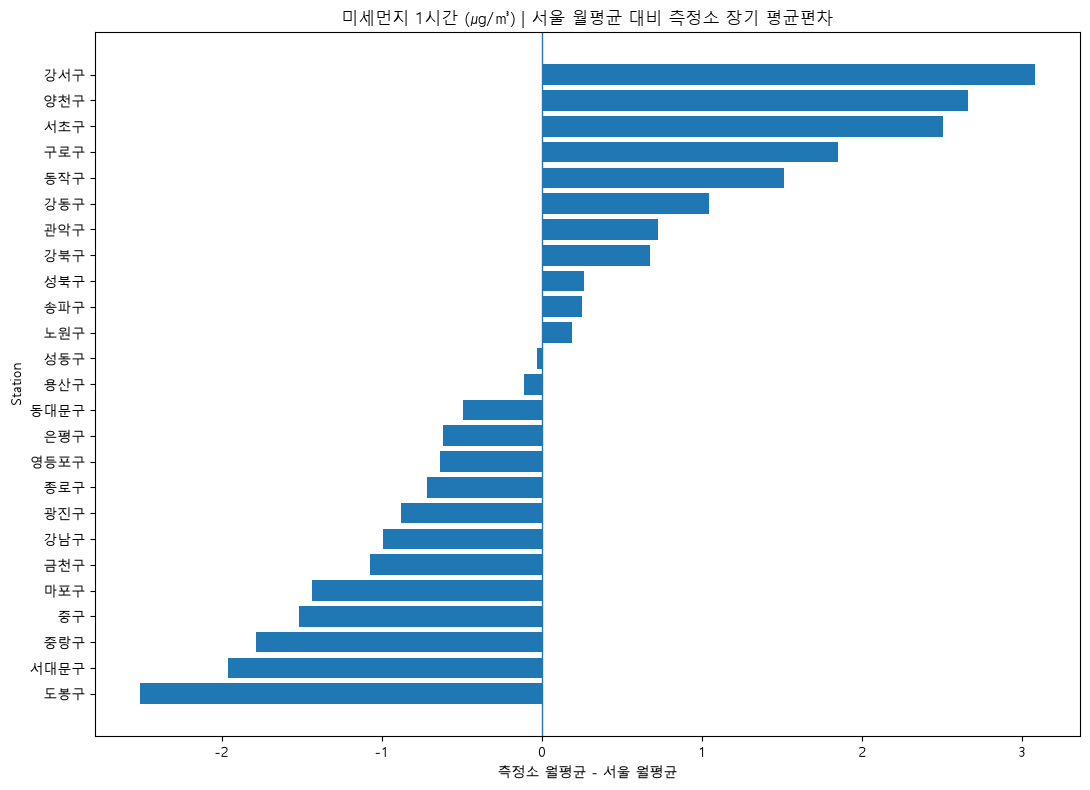

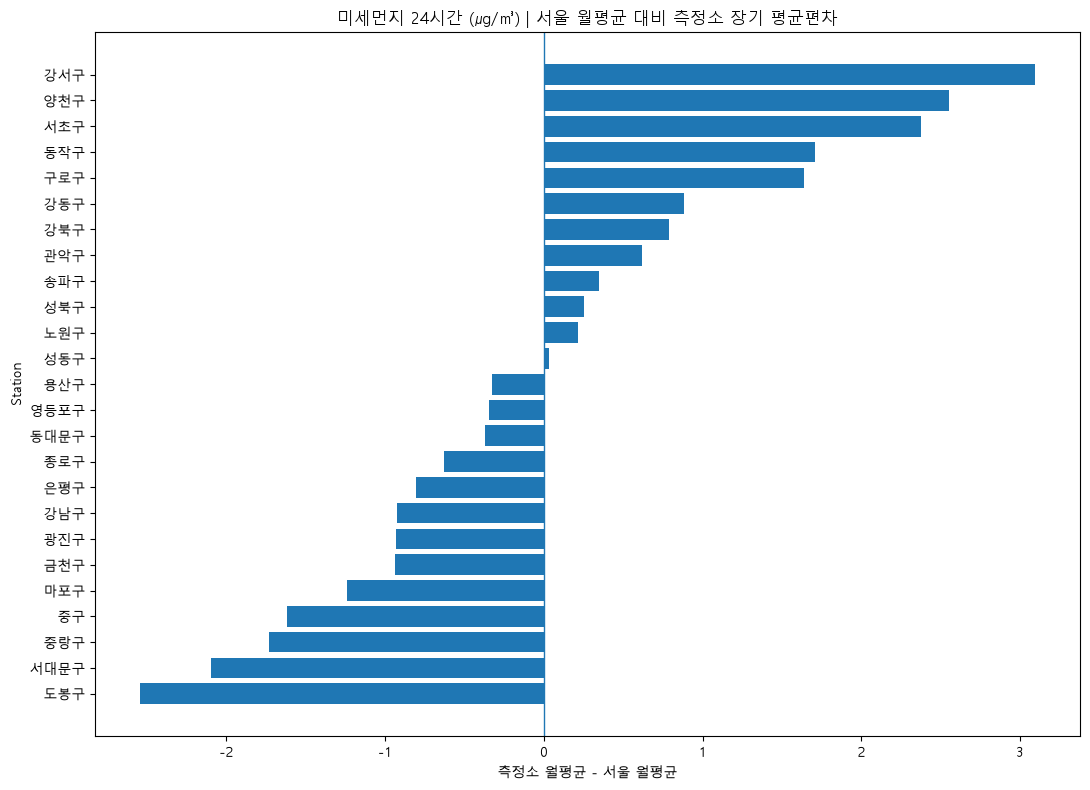

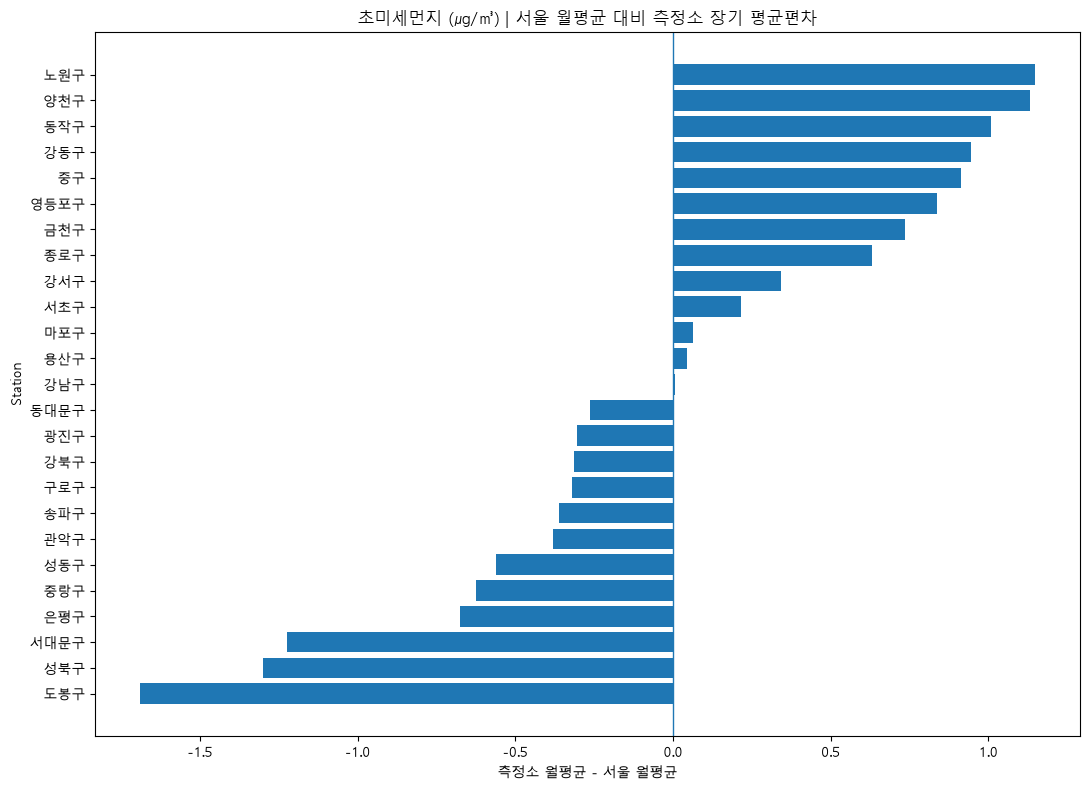

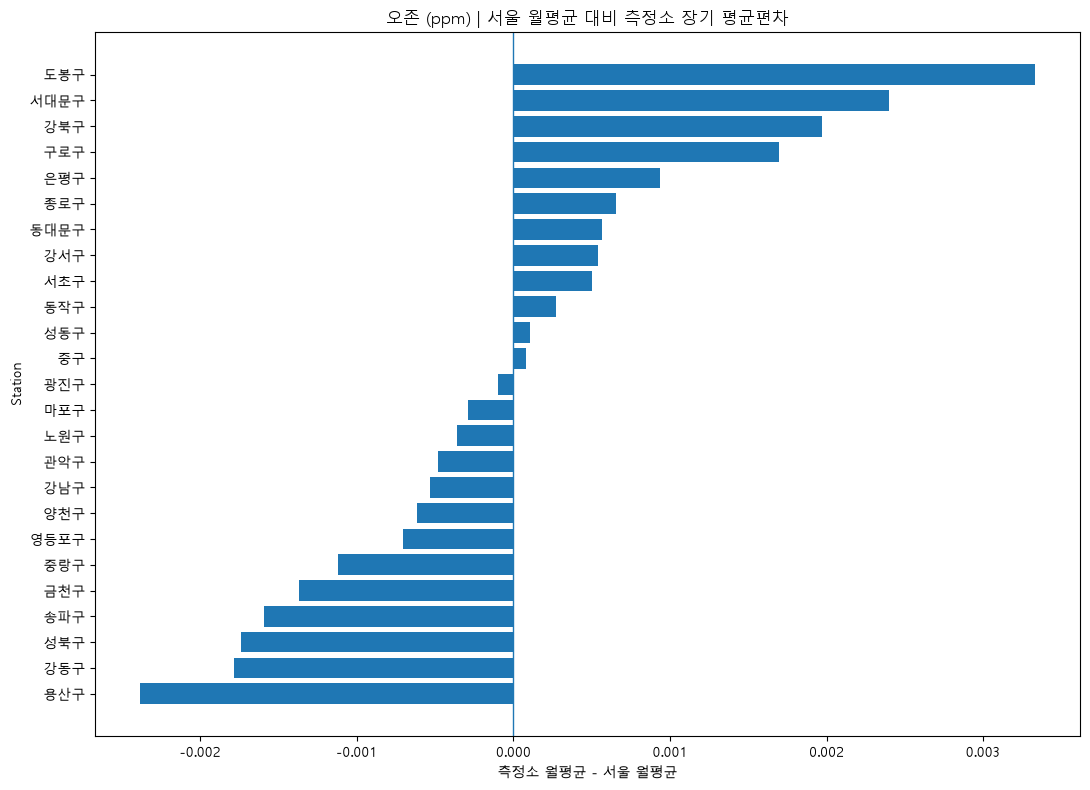

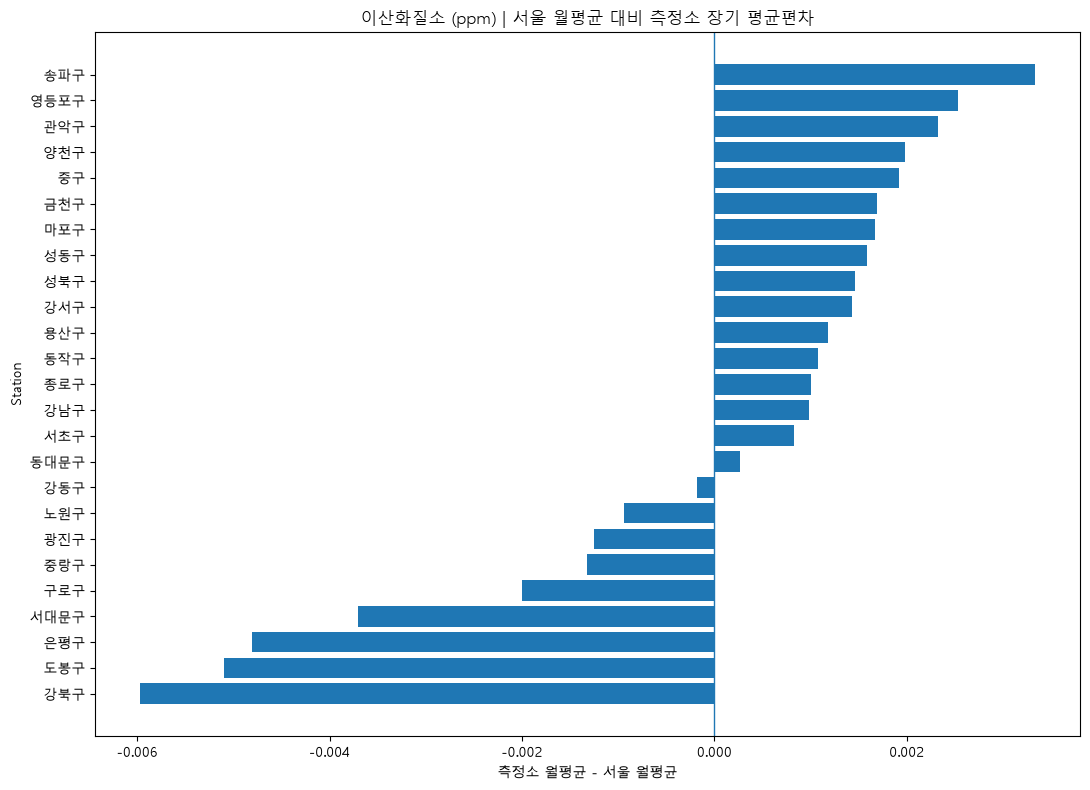

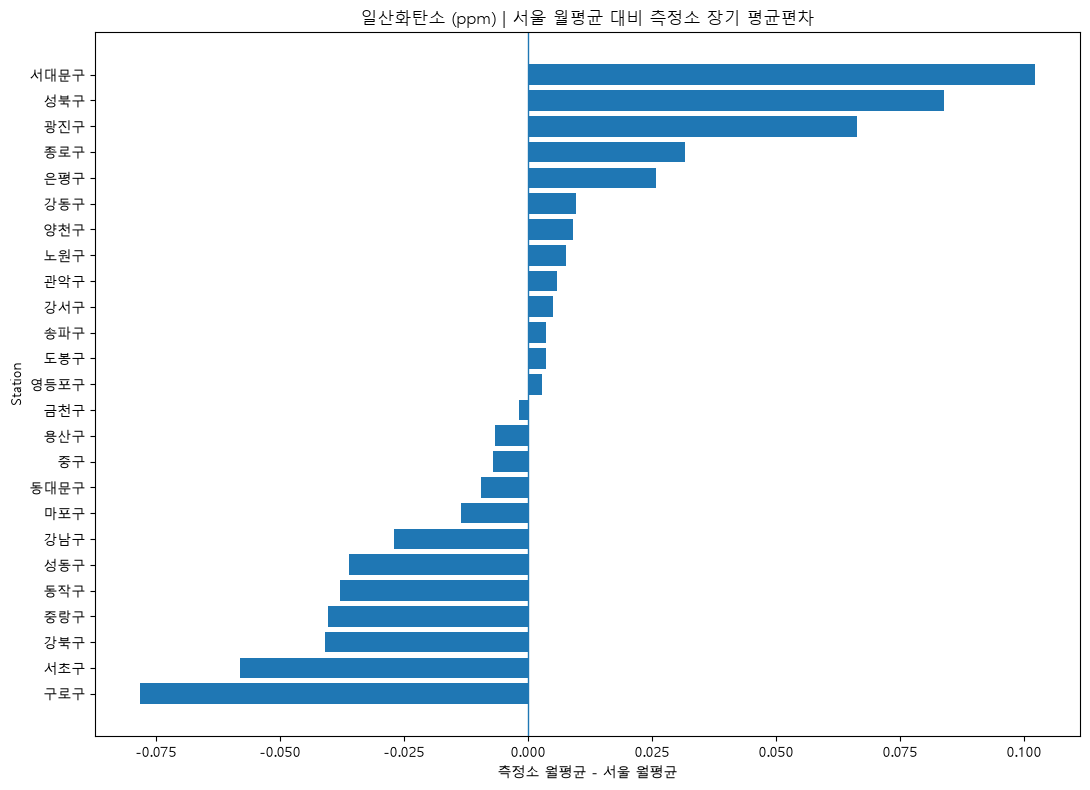

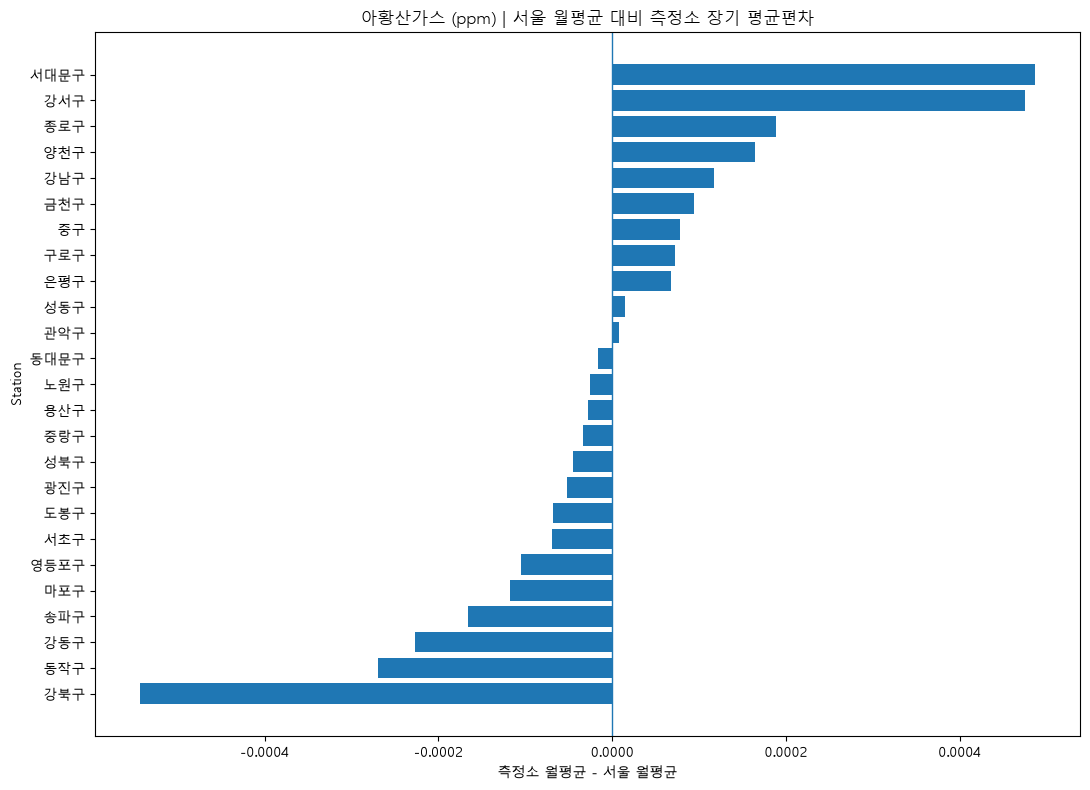

In [25]:
for pollutant in AVAILABLE_POLLUTANTS:
    temp = (
        regional_summary[
            regional_summary["pollutant"]
            == pollutant
        ]
        .sort_values(
            "mean_delta_seoul"
        )
    )

    plt.figure(
        figsize=(11, max(7, len(temp) * 0.32))
    )

    plt.barh(
        temp["station"],
        temp["mean_delta_seoul"]
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.title(
        f"{POLLUTANTS[pollutant]} | "
        "서울 월평균 대비 측정소 장기 평균편차"
    )

    plt.xlabel(
        "측정소 월평균 - 서울 월평균"
    )

    plt.ylabel("Station")
    plt.tight_layout()
    plt.show()

In [26]:
regional_conclusion_rows = []

for pollutant in AVAILABLE_POLLUTANTS:
    temp = regional_summary[
        regional_summary["pollutant"]
        == pollutant
    ].copy()

    if len(temp) == 0:
        continue

    lowest = temp.loc[
        temp["mean_delta_seoul"].idxmin()
    ]

    highest = temp.loc[
        temp["mean_delta_seoul"].idxmax()
    ]

    most_consistently_below = temp.loc[
        temp["below_seoul_rate"].idxmax()
    ]

    regional_conclusion_rows.append({
        "pollutant": pollutant,
        "label": POLLUTANTS[pollutant],
        "lowest_mean_station": lowest["station"],
        "lowest_mean_delta": lowest["mean_delta_seoul"],
        "highest_mean_station": highest["station"],
        "highest_mean_delta": highest["mean_delta_seoul"],
        "most_consistently_below_station": most_consistently_below["station"],
        "below_seoul_rate": most_consistently_below["below_seoul_rate"],
        "station_delta_std_median": temp["std_delta_seoul"].median()
    })

regional_conclusion = pd.DataFrame(
    regional_conclusion_rows
)

display(regional_conclusion)

,pollutant,label,lowest_mean_station,lowest_mean_delta,highest_mean_station,highest_mean_delta,most_consistently_below_station,below_seoul_rate,station_delta_std_median
0,pm10_1h,미세먼지 1시간 (㎍/㎥),도봉구,-2.5096,강서구,3.0797,도봉구,0.8602,2.8013
1,pm10_24h,미세먼지 24시간 (㎍/㎥),도봉구,-2.5445,강서구,3.0945,도봉구,0.7742,2.6508
2,pm25,초미세먼지 (㎍/㎥),도봉구,-1.6906,노원구,1.1492,도봉구,0.8172,1.8417
3,o3,오존 (ppm),용산구,-0.0024,도봉구,0.0033,성북구,0.8817,0.0023
4,no2,이산화질소 (ppm),강북구,-0.0060,송파구,0.0033,도봉구,1.0000,0.0022
5,co,일산화탄소 (ppm),구로구,-0.0783,서대문구,0.1023,동작구,0.9677,0.0448
6,so2,아황산가스 (ppm),강북구,-0.0005,서대문구,0.0005,강북구,0.9785,0.0004


In [27]:
region_lines = []

for _, row in regional_conclusion.iterrows():
    region_lines.append(
        f"- **{row['label']}**: "
        f"장기 평균 상대편차가 가장 낮은 측정소는 "
        f"`{row['lowest_mean_station']}`, "
        f"가장 높은 측정소는 `{row['highest_mean_station']}`. "
        f"`{row['most_consistently_below_station']}`는 "
        f"분석 월의 {row['below_seoul_rate']:.1%}에서 "
        f"서울 평균보다 낮았다."
    )

display(
    Markdown(
        "### E. 지역 차이 결론\n\n"
        + "\n".join(region_lines)
        + "\n\n> 지역 편차는 측정소 위치와 주변 환경의 영향을 포함하므로 "
        + "이를 자치구 자체의 인과적 특성으로 단정하지 않는다."
    )
)

### E. 지역 차이 결론

- **미세먼지 1시간 (㎍/㎥)**: 장기 평균 상대편차가 가장 낮은 측정소는 `도봉구`, 가장 높은 측정소는 `강서구`. `도봉구`는 분석 월의 86.0%에서 서울 평균보다 낮았다.
- **미세먼지 24시간 (㎍/㎥)**: 장기 평균 상대편차가 가장 낮은 측정소는 `도봉구`, 가장 높은 측정소는 `강서구`. `도봉구`는 분석 월의 77.4%에서 서울 평균보다 낮았다.
- **초미세먼지 (㎍/㎥)**: 장기 평균 상대편차가 가장 낮은 측정소는 `도봉구`, 가장 높은 측정소는 `노원구`. `도봉구`는 분석 월의 81.7%에서 서울 평균보다 낮았다.
- **오존 (ppm)**: 장기 평균 상대편차가 가장 낮은 측정소는 `용산구`, 가장 높은 측정소는 `도봉구`. `성북구`는 분석 월의 88.2%에서 서울 평균보다 낮았다.
- **이산화질소 (ppm)**: 장기 평균 상대편차가 가장 낮은 측정소는 `강북구`, 가장 높은 측정소는 `송파구`. `도봉구`는 분석 월의 100.0%에서 서울 평균보다 낮았다.
- **일산화탄소 (ppm)**: 장기 평균 상대편차가 가장 낮은 측정소는 `구로구`, 가장 높은 측정소는 `서대문구`. `동작구`는 분석 월의 96.8%에서 서울 평균보다 낮았다.
- **아황산가스 (ppm)**: 장기 평균 상대편차가 가장 낮은 측정소는 `강북구`, 가장 높은 측정소는 `서대문구`. `강북구`는 분석 월의 97.8%에서 서울 평균보다 낮았다.

> 지역 편차는 측정소 위치와 주변 환경의 영향을 포함하므로 이를 자치구 자체의 인과적 특성으로 단정하지 않는다.

# 11. F. 이전 분석 가설 재검증

이전 분석의 핵심 가설은 다음과 같았다.

1. PM10·PM2.5는 시간대보다 **월별 계절성**이 더 중요한가?
2. 오존은 **시간대 패턴**이 강한가?
3. 지역 차이는 존재하지만 **월·시간 효과보다 상대적으로 작은가?**

이번에는 이를 직접 비교하기 위해 세 축의 변동계수(CV)를 계산한다.

```text
month_cv   = 12개월 평균값의 표준편차 / 전체 평균
hour_cv    = 24시간 평균값의 표준편차 / 전체 평균
station_cv = 25개 측정소 장기평균의 표준편차 / 전체 평균
```

CV는 서로 단위가 다른 오염물질의 상대적 패턴 강도를 비교하기 위한 **탐색적 지표**이며, 인과효과나 분산설명률(eta²)과 동일하지 않다.


In [28]:
variation_rows = []

complete_air = air[
    air["year"].between(
        2019,
        2025
    )
].copy()

station_long_mean = (
    complete_air
    .groupby(
        "station"
    )[AVAILABLE_POLLUTANTS]
    .mean()
)

for pollutant in AVAILABLE_POLLUTANTS:
    overall = complete_air[
        pollutant
    ].mean()

    month_values = (
        season_profile[
            pollutant
        ]
        .dropna()
    )

    hour_values = (
        city_hour_profile[
            pollutant
        ]
        .dropna()
    )

    station_values = (
        station_long_mean[
            pollutant
        ]
        .dropna()
    )

    def cv(values, mean_ref):
        if mean_ref == 0:
            return np.nan

        return (
            values.std(ddof=0)
            /
            mean_ref
        )

    month_cv = cv(
        month_values,
        overall
    )

    hour_cv = cv(
        hour_values,
        overall
    )

    station_cv = cv(
        station_values,
        overall
    )

    strengths = {
        "월": month_cv,
        "시간": hour_cv,
        "지역": station_cv
    }

    strongest_axis = max(
        strengths,
        key=lambda k: (
            -np.inf
            if pd.isna(strengths[k])
            else strengths[k]
        )
    )

    variation_rows.append({
        "pollutant": pollutant,
        "label": POLLUTANTS[pollutant],
        "month_cv": month_cv,
        "hour_cv": hour_cv,
        "station_cv": station_cv,
        "strongest_axis": strongest_axis
    })

variation_summary = pd.DataFrame(
    variation_rows
)

display(
    variation_summary
    .sort_values(
        "month_cv",
        ascending=False
    )
)

,pollutant,label,month_cv,hour_cv,station_cv,strongest_axis
3,o3,오존 (ppm),0.3267,0.3176,0.0454,월
0,pm10_1h,미세먼지 1시간 (㎍/㎥),0.3134,0.0461,0.0437,월
2,pm25,초미세먼지 (㎍/㎥),0.2990,0.0239,0.0395,월
1,pm10_24h,미세먼지 24시간 (㎍/㎥),0.2982,0.0276,0.0420,월
4,no2,이산화질소 (ppm),0.2870,0.1417,0.1171,월
5,co,일산화탄소 (ppm),0.2093,0.0762,0.0942,월
6,so2,아황산가스 (ppm),0.0917,0.0363,0.0712,월


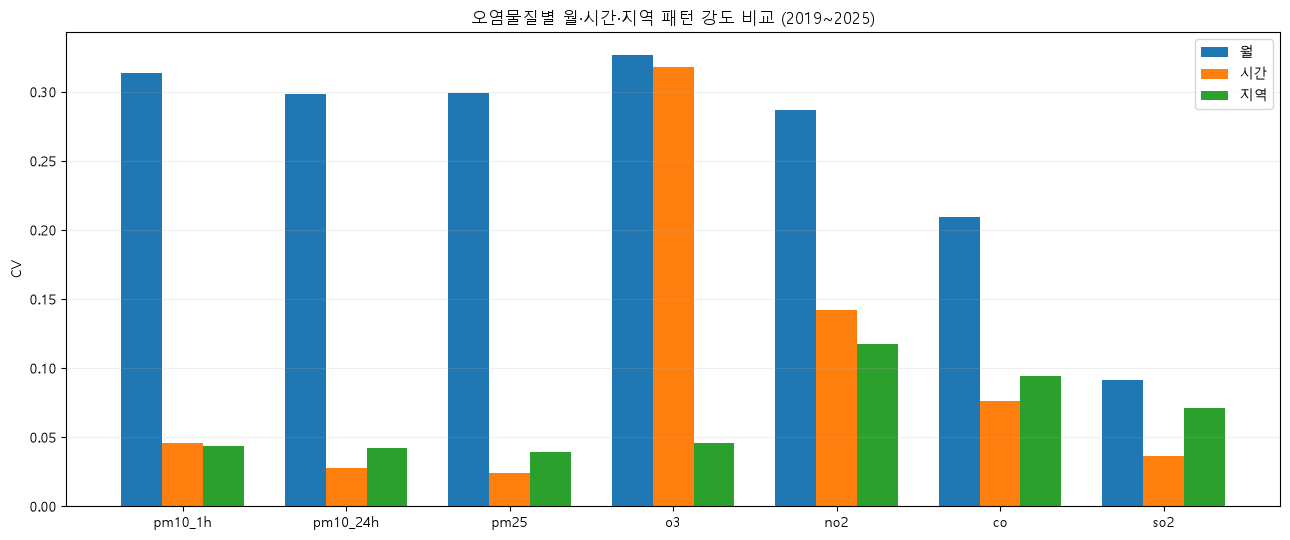

In [29]:
x = np.arange(
    len(variation_summary)
)

width = 0.25

plt.figure(
    figsize=(13, 5.5)
)

plt.bar(
    x - width,
    variation_summary["month_cv"],
    width=width,
    label="월"
)

plt.bar(
    x,
    variation_summary["hour_cv"],
    width=width,
    label="시간"
)

plt.bar(
    x + width,
    variation_summary["station_cv"],
    width=width,
    label="지역"
)

plt.xticks(
    x,
    variation_summary["pollutant"]
)

plt.ylabel("CV")
plt.title(
    "오염물질별 월·시간·지역 패턴 강도 비교 (2019~2025)"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [30]:
hypothesis_lines = []

# PM hypotheses
for pm in [
    p for p in ["pm10_1h", "pm10_24h", "pm25"]
    if p in AVAILABLE_POLLUTANTS
]:
    row = variation_summary[
        variation_summary["pollutant"]
        == pm
    ].iloc[0]

    if row["month_cv"] > row["hour_cv"]:
        result = (
            "월별 변동이 시간대 변동보다 크게 나타나 "
            "기존 계절성 가설을 지지한다."
        )
    else:
        result = (
            "시간대 변동이 월별 변동보다 같거나 크게 나타나 "
            "기존 계절성 가설을 그대로 유지하기 어렵다."
        )

    hypothesis_lines.append(
        f"- **{POLLUTANTS[pm]}:** "
        f"month CV={row['month_cv']:.3f}, "
        f"hour CV={row['hour_cv']:.3f}, "
        f"station CV={row['station_cv']:.3f}. "
        f"{result}"
    )


# O3 hypothesis
if "o3" in AVAILABLE_POLLUTANTS:
    row = variation_summary[
        variation_summary["pollutant"]
        == "o3"
    ].iloc[0]

    hypothesis_lines.append(
        f"- **오존:** "
        f"month CV={row['month_cv']:.3f}, "
        f"hour CV={row['hour_cv']:.3f}, "
        f"station CV={row['station_cv']:.3f}. "
        f"시간대 CV가 다른 오염물질 대비 어느 정도 큰지와 "
        f"peak hour를 함께 보아 시간대 효과 가설을 판단한다."
    )


# Regional relative hypothesis
for _, row in variation_summary.iterrows():
    temporal_max = max(
        row["month_cv"],
        row["hour_cv"]
    )

    if row["station_cv"] < temporal_max:
        text = (
            "지역 변동보다 월/시간 중 더 큰 시간적 변동이 우세."
        )
    else:
        text = (
            "지역 변동이 월/시간 변동과 비슷하거나 더 큼."
        )

    hypothesis_lines.append(
        f"- **{row['label']} 지역효과 비교:** "
        f"station CV={row['station_cv']:.3f}. "
        f"{text}"
    )

display(
    Markdown(
        "### F. 가설 재검증 결과\n\n"
        + "\n".join(
            hypothesis_lines
        )
    )
)

### F. 가설 재검증 결과

- **미세먼지 1시간 (㎍/㎥):** month CV=0.313, hour CV=0.046, station CV=0.044. 월별 변동이 시간대 변동보다 크게 나타나 기존 계절성 가설을 지지한다.
- **미세먼지 24시간 (㎍/㎥):** month CV=0.298, hour CV=0.028, station CV=0.042. 월별 변동이 시간대 변동보다 크게 나타나 기존 계절성 가설을 지지한다.
- **초미세먼지 (㎍/㎥):** month CV=0.299, hour CV=0.024, station CV=0.040. 월별 변동이 시간대 변동보다 크게 나타나 기존 계절성 가설을 지지한다.
- **오존:** month CV=0.327, hour CV=0.318, station CV=0.045. 시간대 CV가 다른 오염물질 대비 어느 정도 큰지와 peak hour를 함께 보아 시간대 효과 가설을 판단한다.
- **미세먼지 1시간 (㎍/㎥) 지역효과 비교:** station CV=0.044. 지역 변동보다 월/시간 중 더 큰 시간적 변동이 우세.
- **미세먼지 24시간 (㎍/㎥) 지역효과 비교:** station CV=0.042. 지역 변동보다 월/시간 중 더 큰 시간적 변동이 우세.
- **초미세먼지 (㎍/㎥) 지역효과 비교:** station CV=0.040. 지역 변동보다 월/시간 중 더 큰 시간적 변동이 우세.
- **오존 (ppm) 지역효과 비교:** station CV=0.045. 지역 변동보다 월/시간 중 더 큰 시간적 변동이 우세.
- **이산화질소 (ppm) 지역효과 비교:** station CV=0.117. 지역 변동보다 월/시간 중 더 큰 시간적 변동이 우세.
- **일산화탄소 (ppm) 지역효과 비교:** station CV=0.094. 지역 변동보다 월/시간 중 더 큰 시간적 변동이 우세.
- **아황산가스 (ppm) 지역효과 비교:** station CV=0.071. 지역 변동보다 월/시간 중 더 큰 시간적 변동이 우세.

# 12. 최종 결론

아래 셀은 앞에서 계산한 결과를 종합해 **데이터 기반 결론**을 자동 작성한다.

결론은 다음 네 층으로 나눈다.

1. 데이터 신뢰성
2. 장기 추세
3. 월·시간·지역 중 어떤 축이 중요한가
4. 러닝 추천용 historical air feature를 어떻게 설계할 것인가


In [31]:
final_lines = []

# ------------------------------------------------------------
# 1) 데이터 품질
# ------------------------------------------------------------
all_25 = (
    len(year_coverage) > 0
    and
    year_coverage["station_count"]
    .eq(25)
    .all()
)

if all_25:
    final_lines.append(
        "### 1. 데이터 품질\n"
        "- 분석 기간의 각 연도에서 25개 측정소가 확인되었다."
    )
else:
    final_lines.append(
        "### 1. 데이터 품질\n"
        "- 일부 연도에서 25개 측정소가 모두 확인되지 않았다. "
        "해당 연도의 지역 비교는 주의가 필요하다."
    )

worst_cov_value = (
    station_year_count[
        "coverage_rate"
    ].min()
)

final_lines.append(
    f"- 가장 낮은 연도×측정소 관측시간 커버리지는 "
    f"{worst_cov_value:.1%}이다."
)

max_missing_rate = (
    missing_by_station_year[
        "missing_rate"
    ].max()
)

max_zero_rate = (
    zero_by_station_year[
        "zero_rate"
    ].max()
)

final_lines.append(
    f"- 최대 결측률은 {max_missing_rate:.1%}, "
    f"최대 0값 비율은 {max_zero_rate:.1%}이다. "
    f"0값은 원자료 정의를 확인하기 전까지 임의 제거하지 않는 것이 안전하다."
)

if pd.notna(latest_2026):
    final_lines.append(
        f"- 2026년 데이터는 "
        f"{latest_2026:%Y-%m-%d %H:%M}까지 존재하므로 "
        f"2026년은 완전연도 장기 추세가 아니라 최근 상태 비교용으로 해석한다."
    )


# ------------------------------------------------------------
# 2) 장기 추세
# ------------------------------------------------------------
final_lines.append(
    "\n### 2. 2019~2025 장기 추세"
)

for _, row in trend_summary.iterrows():
    final_lines.append(
        f"- {row['label']}: "
        f"{row['direction']} "
        f"({row['slope_pct_per_year']:+.2f}%/년)."
    )


# ------------------------------------------------------------
# 3) season / hour / region
# ------------------------------------------------------------
final_lines.append(
    "\n### 3. 계절·시간·지역 패턴"
)

for _, row in variation_summary.iterrows():
    vals = {
        "월": row["month_cv"],
        "시간": row["hour_cv"],
        "지역": row["station_cv"]
    }

    ordered = sorted(
        vals.items(),
        key=lambda x: (
            -np.inf
            if pd.isna(x[1])
            else x[1]
        ),
        reverse=True
    )

    order_text = " > ".join(
        [
            f"{name}({value:.3f})"
            for name, value in ordered
        ]
    )

    final_lines.append(
        f"- {row['label']}: "
        f"상대 변동 강도는 {order_text}."
    )


# ------------------------------------------------------------
# 4) specific feature implications
# ------------------------------------------------------------
feature_lines = []

for _, row in variation_summary.iterrows():
    use = []

    if row["month_cv"] >= row["station_cv"]:
        use.append("month")

    if row["hour_cv"] >= row["station_cv"]:
        use.append("hour")

    if row["station_cv"] > 0:
        use.append("district adjustment")

    feature_lines.append(
        f"- {row['label']}: "
        + ", ".join(use)
    )

final_lines.append(
    "\n### 4. 추천 feature 설계에 대한 결론"
)

final_lines.append(
    "- 대기질을 하나의 고정 지역 점수로 만들기보다 "
    "`district × month × hour` 조건부 climatology로 만드는 방향이 적절한지 "
    "위의 월·시간·지역 CV 비교 결과를 기준으로 판단한다."
)

final_lines.extend(
    feature_lines
)

final_lines.append(
    "\n- **2026년은 baseline 학습용 완전연도로 바로 섞지 않고**, "
    "최근 drift 확인 및 업데이트 판단용으로 따로 유지하는 것이 안전하다."
)

final_lines.append(
    "- 이 단계의 목적은 AirScore 확정이 아니라 "
    "어떤 축의 historical information을 다음 feature table에 보존할지 결정하는 것이다."
)

FINAL_REPORT = "\n".join(
    final_lines
)

display(
    Markdown(
        "# 2019~2026 서울 대기질 최종 분석 결론\n\n"
        + FINAL_REPORT
    )
)

# 2019~2026 서울 대기질 최종 분석 결론

### 1. 데이터 품질
- 분석 기간의 각 연도에서 25개 측정소가 확인되었다.
- 가장 낮은 연도×측정소 관측시간 커버리지는 98.5%이다.
- 최대 결측률은 100.0%, 최대 0값 비율은 16.9%이다. 0값은 원자료 정의를 확인하기 전까지 임의 제거하지 않는 것이 안전하다.
- 2026년 데이터는 2026-09-25 16:00까지 존재하므로 2026년은 완전연도 장기 추세가 아니라 최근 상태 비교용으로 해석한다.

### 2. 2019~2025 장기 추세
- 미세먼지 1시간 (㎍/㎥): 하락 경향 (-3.26%/년).
- 미세먼지 24시간 (㎍/㎥): 하락 경향 (-3.32%/년).
- 초미세먼지 (㎍/㎥): 하락 경향 (-4.14%/년).
- 오존 (ppm): 상승 경향 (+5.54%/년).
- 이산화질소 (ppm): 하락 경향 (-6.90%/년).
- 일산화탄소 (ppm): 하락 경향 (-3.49%/년).
- 아황산가스 (ppm): 하락 경향 (-5.42%/년).

### 3. 계절·시간·지역 패턴
- 미세먼지 1시간 (㎍/㎥): 상대 변동 강도는 월(0.313) > 시간(0.046) > 지역(0.044).
- 미세먼지 24시간 (㎍/㎥): 상대 변동 강도는 월(0.298) > 지역(0.042) > 시간(0.028).
- 초미세먼지 (㎍/㎥): 상대 변동 강도는 월(0.299) > 지역(0.040) > 시간(0.024).
- 오존 (ppm): 상대 변동 강도는 월(0.327) > 시간(0.318) > 지역(0.045).
- 이산화질소 (ppm): 상대 변동 강도는 월(0.287) > 시간(0.142) > 지역(0.117).
- 일산화탄소 (ppm): 상대 변동 강도는 월(0.209) > 지역(0.094) > 시간(0.076).
- 아황산가스 (ppm): 상대 변동 강도는 월(0.092) > 지역(0.071) > 시간(0.036).

### 4. 추천 feature 설계에 대한 결론
- 대기질을 하나의 고정 지역 점수로 만들기보다 `district × month × hour` 조건부 climatology로 만드는 방향이 적절한지 위의 월·시간·지역 CV 비교 결과를 기준으로 판단한다.
- 미세먼지 1시간 (㎍/㎥): month, hour, district adjustment
- 미세먼지 24시간 (㎍/㎥): month, district adjustment
- 초미세먼지 (㎍/㎥): month, district adjustment
- 오존 (ppm): month, hour, district adjustment
- 이산화질소 (ppm): month, hour, district adjustment
- 일산화탄소 (ppm): month, district adjustment
- 아황산가스 (ppm): month, district adjustment

- **2026년은 baseline 학습용 완전연도로 바로 섞지 않고**, 최근 drift 확인 및 업데이트 판단용으로 따로 유지하는 것이 안전하다.
- 이 단계의 목적은 AirScore 확정이 아니라 어떤 축의 historical information을 다음 feature table에 보존할지 결정하는 것이다.

# 13. 오염물질별 최종 요약표

한 표에서 장기 추세·계절성·시간대·지역성을 함께 확인한다.


In [32]:
final_summary = (
    trend_summary[
        [
            "pollutant",
            "label",
            "slope_pct_per_year",
            "2019_to_2025_change_pct",
            "direction"
        ]
    ]
    .merge(
        seasonality_summary[
            [
                "pollutant",
                "peak_month",
                "low_month",
                "month_cv"
            ]
        ],
        on="pollutant",
        how="outer"
    )
    .merge(
        diurnal_summary[
            [
                "pollutant",
                "peak_hour",
                "low_hour",
                "hour_cv"
            ]
        ],
        on="pollutant",
        how="outer"
    )
    .merge(
        variation_summary[
            [
                "pollutant",
                "station_cv",
                "strongest_axis"
            ]
        ],
        on="pollutant",
        how="outer"
    )
)

if len(ytd_compare):
    final_summary = final_summary.merge(
        ytd_compare[
            [
                "pollutant",
                "2026_vs_history_pct"
            ]
        ],
        on="pollutant",
        how="left"
    )

display(final_summary)

,pollutant,label,slope_pct_per_year,2019_to_2025_change_pct,direction,peak_month,low_month,month_cv,peak_hour,low_hour,hour_cv,station_cv,strongest_axis,2026_vs_history_pct
0,co,일산화탄소 (ppm),-3.4932,-20.5341,하락 경향,1,8,0.2090,9,16,0.0762,0.0942,월,-14.7726
1,no2,이산화질소 (ppm),-6.9044,-35.5388,하락 경향,1,8,0.2869,8,15,0.1418,0.1171,월,-25.2557
2,o3,오존 (ppm),5.5433,34.7995,상승 경향,6,12,0.3266,16,7,0.3169,0.0454,월,12.2342
3,pm10_1h,미세먼지 1시간 (㎍/㎥),-3.2552,-20.3059,하락 경향,3,9,0.3136,11,6,0.0461,0.0437,월,-12.0429
4,pm10_24h,미세먼지 24시간 (㎍/㎥),-3.3197,-20.6276,하락 경향,3,9,0.2981,20,8,0.0276,0.0420,월,NaN
5,pm25,초미세먼지 (㎍/㎥),-4.1352,-23.2917,하락 경향,3,9,0.2988,11,6,0.0239,0.0395,월,-9.3592
6,so2,아황산가스 (ppm),-5.4167,-30.2166,하락 경향,1,9,0.0917,11,6,0.0363,0.0712,월,-16.4406


# 14. 결과 저장

분석 결과를 다음 단계에서 바로 사용할 수 있도록 CSV와 Markdown으로 저장한다.


In [33]:
CONCLUSION_DIR = (
    ANALYSIS_DIR
    / "conclusion"
)

CONCLUSION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

year_coverage.to_csv(
    CONCLUSION_DIR
    / "01_year_coverage.csv",
    index=False,
    encoding="utf-8-sig"
)

quality_summary.to_csv(
    CONCLUSION_DIR
    / "02_quality_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

trend_summary.to_csv(
    CONCLUSION_DIR
    / "03_long_term_trend.csv",
    index=False,
    encoding="utf-8-sig"
)

ytd_compare.to_csv(
    CONCLUSION_DIR
    / "04_2026_same_period_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

seasonality_summary.to_csv(
    CONCLUSION_DIR
    / "05_seasonality_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

diurnal_summary.to_csv(
    CONCLUSION_DIR
    / "06_diurnal_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

regional_summary.to_csv(
    CONCLUSION_DIR
    / "07_regional_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

variation_summary.to_csv(
    CONCLUSION_DIR
    / "08_month_hour_station_variation.csv",
    index=False,
    encoding="utf-8-sig"
)

final_summary.to_csv(
    CONCLUSION_DIR
    / "09_final_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

with open(
    CONCLUSION_DIR
    / "10_final_conclusion.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(
        "# 2019~2026 서울 대기질 최종 분석 결론\n\n"
    )
    f.write(
        FINAL_REPORT
    )

print("저장 완료:")
print(CONCLUSION_DIR)

저장 완료:
C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\conclusion


# 15. 다음 단계

이 노트북에서 최종적으로 확인한 패턴을 바탕으로 다음 단계에서 historical air climatology를 생성한다.

권장 구조:

```text
district
month
hour

PM10 mean / median / p90
PM2.5 mean / median / p90
O3 mean / median / p90
NO2 mean / median / p90
CO mean / median / p90
SO2 mean / median / p90

서울 평균 대비 상대편차
observation_count
```

즉 다음 단계의 핵심 테이블은:

```text
gu × month × hour
```

이다.

이 테이블이 완성되면 러닝 코스의 자치구와 연결해 **historical air context feature**로 사용할 수 있다.
